In [3]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"

DATA_PATHS = [
    os.path.join(BASE_DIR, "data_random_with_random_variances_total_v2.csv"),
    os.path.join(BASE_DIR, "data_physics_with_variances_total.csv"),
]

# hard cap per dataset
NROWS_PER_DATASET = 2_500_000

# Input model for fine-tuning
PRETRAINED_MODEL_PATH = os.path.join(
    BASE_DIR, "random_v2_model_finetuned_best_v2.pth"
)

# Output paths
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "combined_random_physics_finetuned_best_v1.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "combined_random_physics_finetuned_last_v1.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "combined_random_physics_finetuned_scalers_v1.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


def validate_required_columns(df, file_path):
    if "mem_len" not in df.columns:
        raise ValueError(f"Required column 'mem_len' not found in {file_path}")
    if "N" not in df.columns:
        raise ValueError(f"Required column 'N' not found in {file_path}")

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError(f"No tap_* columns found in {file_path}")
    if not var_cols:
        raise ValueError(f"No var_* columns found in {file_path}")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch in {file_path}: "
            f"{len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {file_path}: {missing}")

    return tap_cols, var_cols


def load_and_merge_data(csv_paths, nrows_per_dataset):
    dfs = []
    reference_tap_cols = None
    reference_var_cols = None

    for path in csv_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Dataset not found: {path}")

        print(f"Loading up to {nrows_per_dataset:,} rows from: {path}")
        df = pd.read_csv(path, nrows=nrows_per_dataset)

        tap_cols, var_cols = validate_required_columns(df, path)

        if reference_tap_cols is None:
            reference_tap_cols = tap_cols
            reference_var_cols = var_cols
        else:
            if tap_cols != reference_tap_cols:
                raise ValueError(
                    f"tap columns do not match across files.\n"
                    f"Reference: {reference_tap_cols[:5]} ... total={len(reference_tap_cols)}\n"
                    f"Current ({path}): {tap_cols[:5]} ... total={len(tap_cols)}"
                )
            if var_cols != reference_var_cols:
                raise ValueError(
                    f"var columns do not match across files.\n"
                    f"Reference: {reference_var_cols[:5]} ... total={len(reference_var_cols)}\n"
                    f"Current ({path}): {var_cols[:5]} ... total={len(var_cols)}"
                )

        df["source_dataset"] = os.path.basename(path)
        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True)
    print(f"Combined rows before filtering: {len(merged):,}")

    return merged, reference_tap_cols, reference_var_cols


# =========================
# Stable Multi-objective Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
      - model outputs unconstrained raw scalar u
      - u is mapped to:
            pred_log = log10(0.5) - softplus(u)
            pred_raw = 10 ** pred_log
      - Huber loss in log10(BER) space
      - Huber loss in raw BER space
      - optional regime weighting based on raw BER
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.7,
        beta_raw=0.3,
        use_regime_weights=False,
        low_thr=1e-6,
        mid_thr=1e-3,
        w_low=1.0,
        w_mid=1.25,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0],
            num_attn_heads=stage_pool_heads[0],
            attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1],
            num_attn_heads=stage_pool_heads[1],
            attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[2],
            attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[3],
            attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Data
# =========================
def prepare_data(csv_paths, batch_size=256, nrows_per_dataset=2_500_000, num_workers=0):
    df, tap_cols, var_cols = load_and_merge_data(csv_paths, nrows_per_dataset)

    df = df[df["mem_len"] != 1].copy()

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    print(f"Rows after cleaning/filtering: {len(df):,}")

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    # Stratify on final merged BER distribution
    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        X_thr, y_log,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_thr, temp_y_log,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 3,
        "seq_feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
        ],
        "global_feature_order": [
            "z0_margin",
            "z1_margin",
            "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
        "data_paths": csv_paths,
        "nrows_per_dataset": nrows_per_dataset,
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during evaluation."
                )

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATHS,
        batch_size=256,
        nrows_per_dataset=NROWS_PER_DATASET,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)
    print(f"Scalers saved to: {SCALER_SAVE_PATH}")

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    if os.path.exists(PRETRAINED_MODEL_PATH):
        print(f"Loading pre-trained model from {PRETRAINED_MODEL_PATH} for fine-tuning...")
        model.load_state_dict(torch.load(PRETRAINED_MODEL_PATH, map_location=device))
        optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
    else:
        print("Pre-trained model not found. Training from scratch...")
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    # More balanced weighting because now both low-BER and high-BER regimes are present
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.01,
        alpha_log=0.6,
        beta_raw=0.4,
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        w_low=1.0,
        w_mid=1.5,
        w_high=3.0,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60
    max_epochs = 100

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False

    for epoch in range(max_epochs):
        model.train()

        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)

            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad
                    and param.data is not None
                    and not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    missing = [p for p in DATA_PATHS if not os.path.exists(p)]
    if missing:
        print("Critical Error: Missing dataset files:")
        for p in missing:
            print(f"  - {p}")
    else:
        print("Using combined training from both datasets:")
        for p in DATA_PATHS:
            print(f"  - {p}")
        print(f"Row cap per dataset: {NROWS_PER_DATASET:,}")

        trained_model = train_engine()

Using combined training from both datasets:
  - ./data_random_with_random_variances_total_v2.csv
  - ./data_physics_with_variances_total.csv
Row cap per dataset: 2,500,000
Executing on: cuda
Loading up to 2,500,000 rows from: ./data_random_with_random_variances_total_v2.csv
Loading up to 2,500,000 rows from: ./data_physics_with_variances_total.csv
Combined rows before filtering: 5,000,000
Rows after cleaning/filtering: 4,109,558
Scalers saved to: ./combined_random_physics_finetuned_scalers_v1.pkl
Loading pre-trained model from ./random_v2_model_finetuned_best_v2.pth for fine-tuning...
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-05 | Train Loss: 0.0308 | Val Loss: 0.0305 | Train RMSE(log10): 0.5485 (~3.54x) | Val RMSE(log10): 0.5436 (~3.50x) | Train MAE(log10): 0.1204 | Val MAE(log10): 0.1196 | Train MAE(raw): 0.022401 | Val MAE(raw): 0.022381
  -> New best model saved at epoch 1 with Val Loss: 0.030481
Epoch 002 | LR: 1.00e-05 | Train Loss: 0.0532 | Val Loss: 0.0532 | Train R

Epoch 032 | LR: 6.25e-07 | Train Loss: 0.0143 | Val Loss: 0.0147 | Train RMSE(log10): 0.2988 (~1.99x) | Val RMSE(log10): 0.3112 (~2.05x) | Train MAE(log10): 0.0687 | Val MAE(log10): 0.0694 | Train MAE(raw): 0.014819 | Val MAE(raw): 0.014824
Epoch 033 | LR: 6.25e-07 | Train Loss: 0.0113 | Val Loss: 0.0116 | Train RMSE(log10): 0.2499 (~1.78x) | Val RMSE(log10): 0.2605 (~1.82x) | Train MAE(log10): 0.0622 | Val MAE(log10): 0.0628 | Train MAE(raw): 0.014453 | Val MAE(raw): 0.014455
Epoch 034 | LR: 6.25e-07 | Train Loss: 0.0056 | Val Loss: 0.0059 | Train RMSE(log10): 0.1700 (~1.48x) | Val RMSE(log10): 0.1810 (~1.52x) | Train MAE(log10): 0.0449 | Val MAE(log10): 0.0454 | Train MAE(raw): 0.013026 | Val MAE(raw): 0.013033
Epoch 035 | LR: 6.25e-07 | Train Loss: 0.0167 | Val Loss: 0.0171 | Train RMSE(log10): 0.3226 (~2.10x) | Val RMSE(log10): 0.3330 (~2.15x) | Train MAE(log10): 0.0762 | Val MAE(log10): 0.0768 | Train MAE(raw): 0.015088 | Val MAE(raw): 0.015097
Epoch 036 | LR: 6.25e-07 | Train Los

Epoch 066 | LR: 1.95e-08 | Train Loss: 0.0150 | Val Loss: 0.0154 | Train RMSE(log10): 0.3027 (~2.01x) | Val RMSE(log10): 0.3144 (~2.06x) | Train MAE(log10): 0.0704 | Val MAE(log10): 0.0711 | Train MAE(raw): 0.014728 | Val MAE(raw): 0.014734
Epoch 067 | LR: 1.95e-08 | Train Loss: 0.0226 | Val Loss: 0.0230 | Train RMSE(log10): 0.3845 (~2.42x) | Val RMSE(log10): 0.3954 (~2.49x) | Train MAE(log10): 0.0899 | Val MAE(log10): 0.0906 | Train MAE(raw): 0.015763 | Val MAE(raw): 0.015771
Epoch 068 | LR: 1.95e-08 | Train Loss: 0.0134 | Val Loss: 0.0136 | Train RMSE(log10): 0.3668 (~2.33x) | Val RMSE(log10): 0.3682 (~2.33x) | Train MAE(log10): 0.0715 | Val MAE(log10): 0.0718 | Train MAE(raw): 0.014777 | Val MAE(raw): 0.014785
Epoch 069 | LR: 1.95e-08 | Train Loss: 0.0169 | Val Loss: 0.0174 | Train RMSE(log10): 0.3368 (~2.17x) | Val RMSE(log10): 0.3503 (~2.24x) | Train MAE(log10): 0.0735 | Val MAE(log10): 0.0744 | Train MAE(raw): 0.014851 | Val MAE(raw): 0.014858
Epoch 070 | LR: 1.95e-08 | Train Los

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER     abs_error  abs_log10_error
0    0.000000  0.499999       0.500000  8.930280e-07     7.872400e-07
1    0.768953  0.499937       0.497142  2.794462e-03  

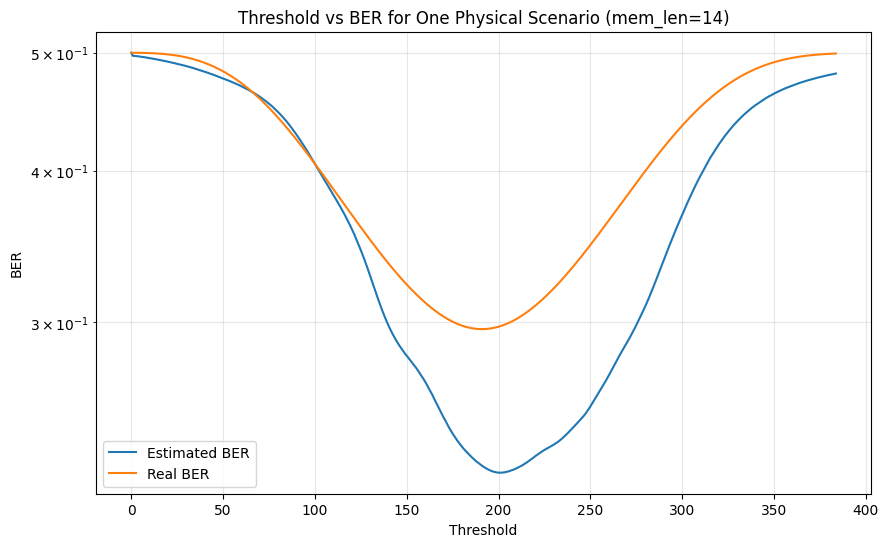

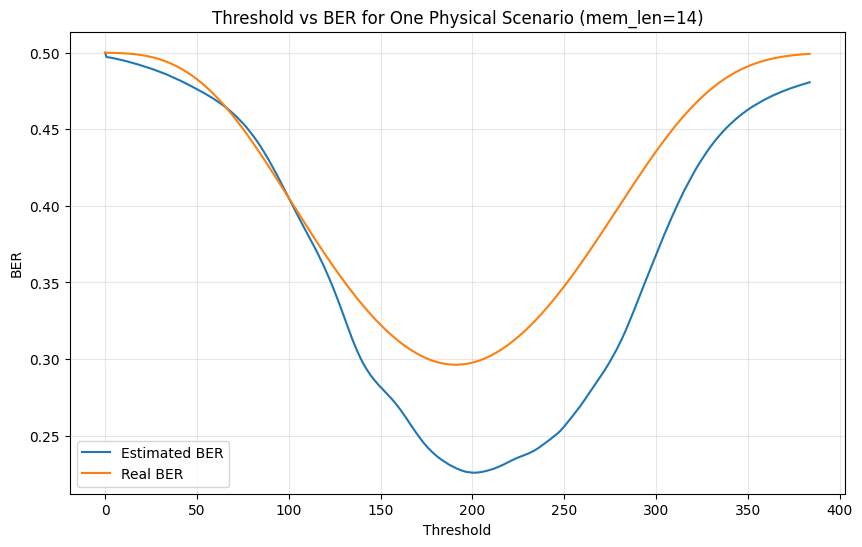

In [4]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "combined_random_physics_finetuned_best_v1.pth"
SCALER_PATH = "combined_random_physics_finetuned_scalers_v1.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
      0 -> scaled tap means multiplied by number of molecules
      1 -> tap variances
      2 -> normalized position
      3 -> abs(scaled tap means)
      4 -> raw-ish log SNR proxy
      5 -> first-position indicator

    Global scalar features:
      0 -> z0 decision margin
      1 -> z1 decision margin
      2 -> harmonic_minus_gap
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        # extra_x contains: [pos, abs tap, snr proxy, first flag]
        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]  # pos, abs, snr, first_flag

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalf(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.10,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error   :", results["abs_error"].mean())
print("Mean abs log10 error :", results["abs_log10_error"].mean())
print("Max  abs log10 error :", results["abs_log10_error"].max())

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])

# =========================
# Plot
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")

plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# MULTITASK

In [1]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"

DATA_PATHS = [
    os.path.join(BASE_DIR, "data_random_with_random_variances_total_v2.csv"),
    os.path.join(BASE_DIR, "data_physics_with_variances_total.csv"),
]

# hard cap per dataset
NROWS_PER_DATASET = 2_500_000

# Output paths
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "combined_random_physics_fulltrain_best_v1_multitask.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "combined_random_physics_fulltrain_last_v1_multitask.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "combined_random_physics_fulltrain_scalers_v1_multitask.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# 10 ordered BER regions -> 9 ordinal thresholds
# classes:
# 0: y < 1e-6
# 1: 1e-6 <= y < 1e-5
# 2: 1e-5 <= y < 1e-4
# 3: 1e-4 <= y < 1e-3
# 4: 1e-3 <= y < 1e-2
# 5: 1e-2 <= y < 1e-1
# 6: 0.1 <= y < 0.2
# 7: 0.2 <= y < 0.3
# 8: 0.3 <= y < 0.4
# 9: 0.4 <= y <= 0.5
ORDINAL_THRESHOLDS = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.2, 0.3, 0.4]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


def validate_required_columns(df, file_path):
    if "mem_len" not in df.columns:
        raise ValueError(f"Required column 'mem_len' not found in {file_path}")
    if "N" not in df.columns:
        raise ValueError(f"Required column 'N' not found in {file_path}")

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError(f"No tap_* columns found in {file_path}")
    if not var_cols:
        raise ValueError(f"No var_* columns found in {file_path}")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch in {file_path}: "
            f"{len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {file_path}: {missing}")

    return tap_cols, var_cols


def load_and_merge_data(csv_paths, nrows_per_dataset):
    dfs = []
    reference_tap_cols = None
    reference_var_cols = None

    for path in csv_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Dataset not found: {path}")

        print(f"Loading up to {nrows_per_dataset:,} rows from: {path}")
        df = pd.read_csv(path, nrows=nrows_per_dataset)

        tap_cols, var_cols = validate_required_columns(df, path)

        if reference_tap_cols is None:
            reference_tap_cols = tap_cols
            reference_var_cols = var_cols
        else:
            if tap_cols != reference_tap_cols:
                raise ValueError(
                    f"tap columns do not match across files.\n"
                    f"Reference: {reference_tap_cols[:5]} ... total={len(reference_tap_cols)}\n"
                    f"Current ({path}): {tap_cols[:5]} ... total={len(tap_cols)}"
                )
            if var_cols != reference_var_cols:
                raise ValueError(
                    f"var columns do not match across files.\n"
                    f"Reference: {reference_var_cols[:5]} ... total={len(reference_var_cols)}\n"
                    f"Current ({path}): {var_cols[:5]} ... total={len(var_cols)}"
                )

        df["source_dataset"] = os.path.basename(path)
        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True)
    print(f"Combined rows before filtering: {len(merged):,}")

    return merged, reference_tap_cols, reference_var_cols


def y_log_to_raw_np(y_log):
    return np.clip(10 ** y_log, EPS, 0.5)


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    labels = np.full_like(y, 9, dtype=np.int64)

    labels[y < 0.4] = 8
    labels[y < 0.3] = 7
    labels[y < 0.2] = 6
    labels[y < 1e-1] = 5
    labels[y < 1e-2] = 4
    labels[y < 1e-3] = 3
    labels[y < 1e-4] = 2
    labels[y < 1e-5] = 1
    labels[y < 1e-6] = 0
    return labels


def region_labels_to_ordinal_targets_np(labels, num_thresholds=NUM_ORDINAL_THRESHOLDS):
    labels = np.asarray(labels).reshape(-1)
    thresholds = np.arange(1, num_thresholds + 1, dtype=np.int64)
    ordinal = (labels[:, None] >= thresholds[None, :]).astype(np.float32)
    return ordinal


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


def compute_region_class_weights(labels_np, num_classes=NUM_REGION_CLASSES, max_weight=8.0):
    counts = np.bincount(labels_np.reshape(-1), minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (num_classes * counts)
    weights = np.sqrt(weights)
    weights = np.clip(weights, 1.0, max_weight)
    return weights.astype(np.float32)


def compute_ordinal_pos_weights_from_region_labels(
    region_labels_np,
    num_thresholds=NUM_ORDINAL_THRESHOLDS,
    max_weight=20.0
):
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels_np, num_thresholds)
    pos_counts = ordinal_targets.sum(axis=0)
    neg_counts = ordinal_targets.shape[0] - pos_counts
    pos_counts = np.maximum(pos_counts, 1.0)
    pos_weight = neg_counts / pos_counts
    pos_weight = np.clip(pos_weight, 1.0, max_weight)
    return pos_weight.astype(np.float32)


# =========================
# Stable Multi-objective Regression Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    def __init__(
        self,
        log_delta=0.35,
        raw_delta=0.003,
        alpha_log=0.85,
        beta_raw=0.15,
        use_regime_weights=False,
        low_thr=1e-4,
        mid_thr=1e-2,
        w_low=3.0,
        w_mid=4.0,
        w_high=1.0,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


class OrdinalBCELoss(nn.Module):
    def __init__(self, pos_weight=None, reduction="mean"):
        super().__init__()
        if pos_weight is not None and not isinstance(pos_weight, torch.Tensor):
            pos_weight = torch.tensor(pos_weight, dtype=torch.float32)
        self.register_buffer("pos_weight", pos_weight if pos_weight is not None else None)
        self.reduction = reduction

    def forward(self, logits, ordinal_targets):
        return F.binary_cross_entropy_with_logits(
            logits,
            ordinal_targets,
            pos_weight=self.pos_weight,
            reduction=self.reduction
        )


class MultiTaskBERLoss(nn.Module):
    def __init__(self, reg_loss, ord_loss, lambda_ord=0.15):
        super().__init__()
        self.reg_loss = reg_loss
        self.ord_loss = ord_loss
        self.lambda_ord = lambda_ord

    def forward(self, pred_raw_unconstrained, ord_logits, target_log, target_ord):
        reg = self.reg_loss(pred_raw_unconstrained, target_log)
        ordl = self.ord_loss(ord_logits, target_ord)
        total = reg + self.lambda_ord * ordl
        return total, reg.detach(), ordl.detach()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.15, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.15, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.08, se=True
            )
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.15):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.15,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0],
            num_attn_heads=stage_pool_heads[0],
            attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1],
            num_attn_heads=stage_pool_heads[1],
            attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[2],
            attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[3],
            attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)

        return pred_raw_unconstrained, ord_logits


# =========================
# Data
# =========================
def prepare_data(csv_paths, batch_size=256, nrows_per_dataset=2_500_000, num_workers=0):
    df, tap_cols, var_cols = load_and_merge_data(csv_paths, nrows_per_dataset)

    df = df[df["mem_len"] != 1].copy()

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    print(f"Rows after cleaning/filtering: {len(df):,}")

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    region_labels = raw_to_region_labels_np(y_raw)
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log,
        t_region, temp_region,
        t_ord, temp_ord
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        X_thr, y_log, region_labels, ordinal_targets,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log,
        v_region, te_region,
        v_ord, te_ord
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_thr, temp_y_log, temp_region, temp_ord,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log.astype(np.float32)),
        torch.from_numpy(t_ord.astype(np.float32)),
        torch.from_numpy(t_region.astype(np.int64)),
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log.astype(np.float32)),
        torch.from_numpy(v_ord.astype(np.float32)),
        torch.from_numpy(v_region.astype(np.int64)),
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log.astype(np.float32)),
        torch.from_numpy(te_ord.astype(np.float32)),
        torch.from_numpy(te_region.astype(np.int64)),
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    class_weights = compute_region_class_weights(t_region, NUM_REGION_CLASSES)
    ordinal_pos_weights = compute_ordinal_pos_weights_from_region_labels(
        t_region,
        num_thresholds=NUM_ORDINAL_THRESHOLDS,
        max_weight=20.0
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 3,
        "seq_feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
        ],
        "global_feature_order": [
            "z0_margin",
            "z1_margin",
            "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "ordinal_thresholds": ORDINAL_THRESHOLDS,
        "num_region_classes": NUM_REGION_CLASSES,
        "class_weights": class_weights.tolist(),
        "ordinal_pos_weights": ordinal_pos_weights.tolist(),
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
        "data_paths": csv_paths,
        "nrows_per_dataset": nrows_per_dataset,
    }

    aux_info = {
        "class_weights": class_weights,
        "ordinal_pos_weights": ordinal_pos_weights,
    }

    return train_loader, val_loader, test_loader, scalers, aux_info, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_reg_loss = 0.0
    total_ord_loss = 0.0

    all_preds_log = []
    all_targets_log = []
    all_pred_regions = []
    all_true_regions = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log, b_ord, b_region in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)
            b_region = b_region.to(device, non_blocking=True)

            pred_raw_unconstrained, ord_logits = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during evaluation.")
            if has_nonfinite_tensor(ord_logits):
                raise RuntimeError("Non-finite ordinal logits detected during evaluation.")

            loss, reg_loss, ord_loss = criterion(
                pred_raw_unconstrained, ord_logits, b_y_log, b_ord
            )

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            pred_region = ordinal_logits_to_region_labels_torch(ord_logits)

            total_loss += loss.item()
            total_reg_loss += reg_loss.item()
            total_ord_loss += ord_loss.item()

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())
            all_pred_regions.append(pred_region.cpu().numpy())
            all_true_regions.append(b_region.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    avg_reg_loss = total_reg_loss / max(len(loader), 1)
    avg_ord_loss = total_ord_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    pred_regions = np.concatenate(all_pred_regions).reshape(-1)
    true_regions = np.concatenate(all_true_regions).reshape(-1)

    region_acc = float(np.mean(pred_regions == true_regions))
    region_mae = float(np.mean(np.abs(pred_regions - true_regions)))

    return {
        "loss": avg_loss,
        "reg_loss": avg_reg_loss,
        "ord_loss": avg_ord_loss,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "factor_error": factor_error,
        "rmse_raw": rmse_raw,
        "mae_raw": mae_raw,
        "region_acc": region_acc,
        "region_mae": region_mae,
    }


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log, _, _ in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained, _ = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-range evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


def evaluate_by_region_class(model, loader, device):
    model.eval()
    all_pred_regions = []
    all_true_regions = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, _, _, b_region in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            _, ord_logits = model(b_seq, b_global, b_thr)
            pred_region = ordinal_logits_to_region_labels_torch(ord_logits)

            all_pred_regions.append(pred_region.cpu().numpy())
            all_true_regions.append(b_region.numpy())

    pred_regions = np.concatenate(all_pred_regions).reshape(-1)
    true_regions = np.concatenate(all_true_regions).reshape(-1)

    results = {}
    for cls in range(NUM_REGION_CLASSES):
        mask = (true_regions == cls)
        if np.any(mask):
            acc = float(np.mean(pred_regions[mask] == true_regions[mask]))
            mae = float(np.mean(np.abs(pred_regions[mask] - true_regions[mask])))
            results[cls] = {
                "count": int(mask.sum()),
                "acc": acc,
                "ordinal_abs_error": mae,
            }
        else:
            results[cls] = None

    return results


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, aux_info, seq_len = prepare_data(
        DATA_PATHS,
        batch_size=256,
        nrows_per_dataset=NROWS_PER_DATASET,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)
    print(f"Scalers saved to: {SCALER_SAVE_PATH}")

    model = BERMultiScaleResCNNBoundedLogHalfMultiTask(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.15,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ).to(device)

    print("Training from scratch...")
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    reg_loss = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.35,
        raw_delta=0.003,
        alpha_log=0.85,
        beta_raw=0.15,
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        w_low=3.0,
        w_mid=4.0,
        w_high=1.0,
    )

    ord_loss = OrdinalBCELoss(
        pos_weight=torch.tensor(aux_info["ordinal_pos_weights"], dtype=torch.float32, device=device),
        reduction="mean"
    )

    criterion = MultiTaskBERLoss(
        reg_loss=reg_loss,
        ord_loss=ord_loss,
        lambda_ord=0.15
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60
    max_epochs = 120

    print(f"Detected sequence length L = {seq_len}")
    print(f"Ordinal thresholds: {ORDINAL_THRESHOLDS}")
    print(f"Ordinal pos weights: {aux_info['ordinal_pos_weights']}")

    training_broke = False

    for epoch in range(max_epochs):
        model.train()

        for batch_idx, (b_seq, b_global, b_thr, b_y_log, b_ord, _) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained, ord_logits = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            if has_nonfinite_tensor(ord_logits):
                print(
                    f"Non-finite ordinal logits detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss, reg_part, ord_part = criterion(
                pred_raw_unconstrained, ord_logits, b_y_log, b_ord
            )

            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad
                    and param.data is not None
                    and not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_metrics = evaluate(model, train_loader, criterion, device)
            val_metrics = evaluate(model, val_loader, criterion, device)
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_metrics["loss"])
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Train Reg: {train_metrics['reg_loss']:.4f} | "
            f"Val Reg: {val_metrics['reg_loss']:.4f} | "
            f"Train Ord: {train_metrics['ord_loss']:.4f} | "
            f"Val Ord: {val_metrics['ord_loss']:.4f} | "
            f"Train RMSE(log10): {train_metrics['rmse_log']:.4f} (~{train_metrics['factor_error']:.2f}x) | "
            f"Val RMSE(log10): {val_metrics['rmse_log']:.4f} (~{val_metrics['factor_error']:.2f}x) | "
            f"Train Region Acc: {train_metrics['region_acc']:.4f} | "
            f"Val Region Acc: {val_metrics['region_acc']:.4f} | "
            f"Train Region MAE: {train_metrics['region_mae']:.4f} | "
            f"Val Region MAE: {val_metrics['region_mae']:.4f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_metrics['loss']:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_metrics = evaluate(model, test_loader, criterion, device)

    print(
        f"Test Loss: {test_metrics['loss']:.4f} | "
        f"Test Reg Loss: {test_metrics['reg_loss']:.4f} | "
        f"Test Ord Loss: {test_metrics['ord_loss']:.4f} | "
        f"Test RMSE(log10): {test_metrics['rmse_log']:.4f} | "
        f"Test MAE(log10): {test_metrics['mae_log']:.4f} | "
        f"Typical multiplicative error: ~{test_metrics['factor_error']:.2f}x | "
        f"Test RMSE(raw): {test_metrics['rmse_raw']:.6f} | "
        f"Test MAE(raw): {test_metrics['mae_raw']:.6f} | "
        f"Test Region Acc: {test_metrics['region_acc']:.4f} | "
        f"Test Region MAE: {test_metrics['region_mae']:.4f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    region_metrics = evaluate_by_region_class(model, test_loader, device)
    print("\nPer-region ordinal diagnostics:")
    region_names = {
        0: "y < 1e-6",
        1: "1e-6 <= y < 1e-5",
        2: "1e-5 <= y < 1e-4",
        3: "1e-4 <= y < 1e-3",
        4: "1e-3 <= y < 1e-2",
        5: "1e-2 <= y < 1e-1",
        6: "0.1 <= y < 0.2",
        7: "0.2 <= y < 0.3",
        8: "0.3 <= y < 0.4",
        9: "0.4 <= y <= 0.5",
    }
    for cls, stats in region_metrics.items():
        if stats is None:
            print(f"class={cls} ({region_names[cls]}): no samples")
        else:
            print(
                f"class={cls} ({region_names[cls]}) | "
                f"count={stats['count']} | "
                f"acc={stats['acc']:.4f} | "
                f"ordinal_abs_error={stats['ordinal_abs_error']:.4f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    missing = [p for p in DATA_PATHS if not os.path.exists(p)]
    if missing:
        print("Critical Error: Missing dataset files:")
        for p in missing:
            print(f"  - {p}")
    else:
        print("Using combined training from both datasets:")
        for p in DATA_PATHS:
            print(f"  - {p}")
        print(f"Row cap per dataset: {NROWS_PER_DATASET:,}")

        trained_model = train_engine()

Using combined training from both datasets:
  - ./data_random_with_random_variances_total_v2.csv
  - ./data_physics_with_variances_total.csv
Row cap per dataset: 2,500,000
Executing on: cuda
Loading up to 2,500,000 rows from: ./data_random_with_random_variances_total_v2.csv
Loading up to 2,500,000 rows from: ./data_physics_with_variances_total.csv
Combined rows before filtering: 5,000,000
Rows after cleaning/filtering: 4,109,558
Scalers saved to: ./combined_random_physics_fulltrain_scalers_v1_multitask.pkl
Training from scratch...
Detected sequence length L = 14
Ordinal thresholds: [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4]
Ordinal pos weights: [1.        1.        1.        1.        1.        1.        1.
 1.2780503 2.7728765]
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0779 | Val Loss: 0.0784 | Train Reg: 0.0706 | Val Reg: 0.0711 | Train Ord: 0.0483 | Val Ord: 0.0484 | Train RMSE(log10): 0.5918 (~3.91x) | Val RMSE(log10): 0.5933 (~3.92x) | Train Region Acc: 0.8389 | Val Re

Epoch 023 | LR: 5.00e-05 | Train Loss: 0.0264 | Val Loss: 0.0264 | Train Reg: 0.0228 | Val Reg: 0.0228 | Train Ord: 0.0240 | Val Ord: 0.0243 | Train RMSE(log10): 0.2376 (~1.73x) | Val RMSE(log10): 0.2416 (~1.74x) | Train Region Acc: 0.9131 | Val Region Acc: 0.9127 | Train Region MAE: 0.0889 | Val Region MAE: 0.0894
Epoch 024 | LR: 5.00e-05 | Train Loss: 0.0164 | Val Loss: 0.0168 | Train Reg: 0.0139 | Val Reg: 0.0143 | Train Ord: 0.0166 | Val Ord: 0.0169 | Train RMSE(log10): 0.1948 (~1.57x) | Val RMSE(log10): 0.2033 (~1.60x) | Train Region Acc: 0.9375 | Val Region Acc: 0.9366 | Train Region MAE: 0.0644 | Val Region MAE: 0.0656
  -> New best model saved at epoch 24 with Val Loss: 0.016822
Epoch 025 | LR: 5.00e-05 | Train Loss: 0.0190 | Val Loss: 0.0194 | Train Reg: 0.0166 | Val Reg: 0.0170 | Train Ord: 0.0158 | Val Ord: 0.0161 | Train RMSE(log10): 0.2123 (~1.63x) | Val RMSE(log10): 0.2196 (~1.66x) | Train Region Acc: 0.9412 | Val Region Acc: 0.9404 | Train Region MAE: 0.0608 | Val Region

Epoch 048 | LR: 6.25e-06 | Train Loss: 0.0127 | Val Loss: 0.0132 | Train Reg: 0.0107 | Val Reg: 0.0111 | Train Ord: 0.0137 | Val Ord: 0.0141 | Train RMSE(log10): 0.1598 (~1.44x) | Val RMSE(log10): 0.1696 (~1.48x) | Train Region Acc: 0.9513 | Val Region Acc: 0.9501 | Train Region MAE: 0.0498 | Val Region MAE: 0.0511
Epoch 049 | LR: 6.25e-06 | Train Loss: 0.0098 | Val Loss: 0.0104 | Train Reg: 0.0081 | Val Reg: 0.0086 | Train Ord: 0.0114 | Val Ord: 0.0118 | Train RMSE(log10): 0.1338 (~1.36x) | Val RMSE(log10): 0.1473 (~1.40x) | Train Region Acc: 0.9584 | Val Region Acc: 0.9573 | Train Region MAE: 0.0422 | Val Region MAE: 0.0435
Epoch 050 | LR: 6.25e-06 | Train Loss: 0.0107 | Val Loss: 0.0112 | Train Reg: 0.0087 | Val Reg: 0.0091 | Train Ord: 0.0133 | Val Ord: 0.0136 | Train RMSE(log10): 0.1368 (~1.37x) | Val RMSE(log10): 0.1502 (~1.41x) | Train Region Acc: 0.9513 | Val Region Acc: 0.9503 | Train Region MAE: 0.0492 | Val Region MAE: 0.0505
Epoch 051 | LR: 6.25e-06 | Train Loss: 0.0086 | V

Epoch 074 | LR: 1.56e-06 | Train Loss: 0.0126 | Val Loss: 0.0132 | Train Reg: 0.0105 | Val Reg: 0.0110 | Train Ord: 0.0138 | Val Ord: 0.0143 | Train RMSE(log10): 0.1479 (~1.41x) | Val RMSE(log10): 0.1606 (~1.45x) | Train Region Acc: 0.9519 | Val Region Acc: 0.9506 | Train Region MAE: 0.0489 | Val Region MAE: 0.0503
Epoch 075 | LR: 7.81e-07 | Train Loss: 0.0100 | Val Loss: 0.0106 | Train Reg: 0.0084 | Val Reg: 0.0089 | Train Ord: 0.0109 | Val Ord: 0.0113 | Train RMSE(log10): 0.1375 (~1.37x) | Val RMSE(log10): 0.1501 (~1.41x) | Train Region Acc: 0.9591 | Val Region Acc: 0.9585 | Train Region MAE: 0.0415 | Val Region MAE: 0.0424
Epoch 076 | LR: 7.81e-07 | Train Loss: 0.0074 | Val Loss: 0.0079 | Train Reg: 0.0060 | Val Reg: 0.0064 | Train Ord: 0.0098 | Val Ord: 0.0102 | Train RMSE(log10): 0.1068 (~1.28x) | Val RMSE(log10): 0.1204 (~1.32x) | Train Region Acc: 0.9638 | Val Region Acc: 0.9627 | Train Region MAE: 0.0365 | Val Region MAE: 0.0377
Epoch 077 | LR: 7.81e-07 | Train Loss: 0.0101 | V

Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER  real_region  predicted_region  \
0    0.000000  0.499999       0.478065            9                 9   
1    0.768953  0.499937       0.490766          

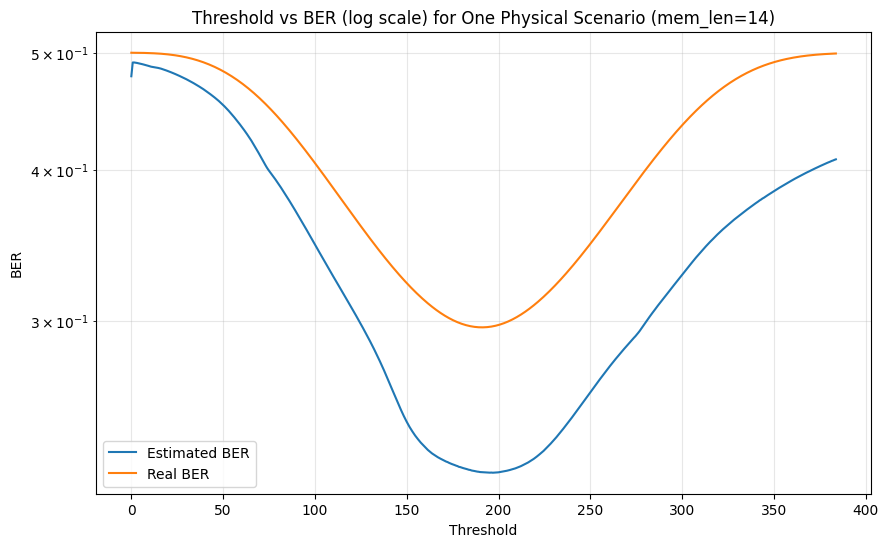

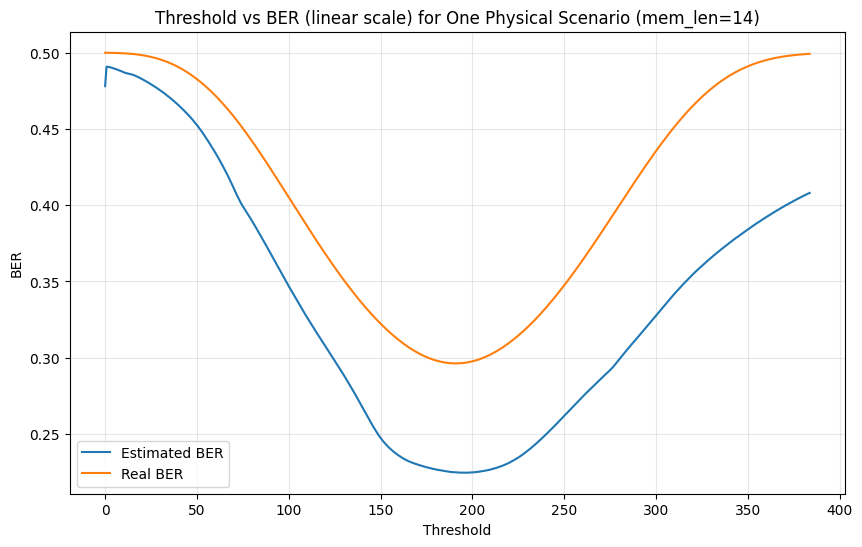

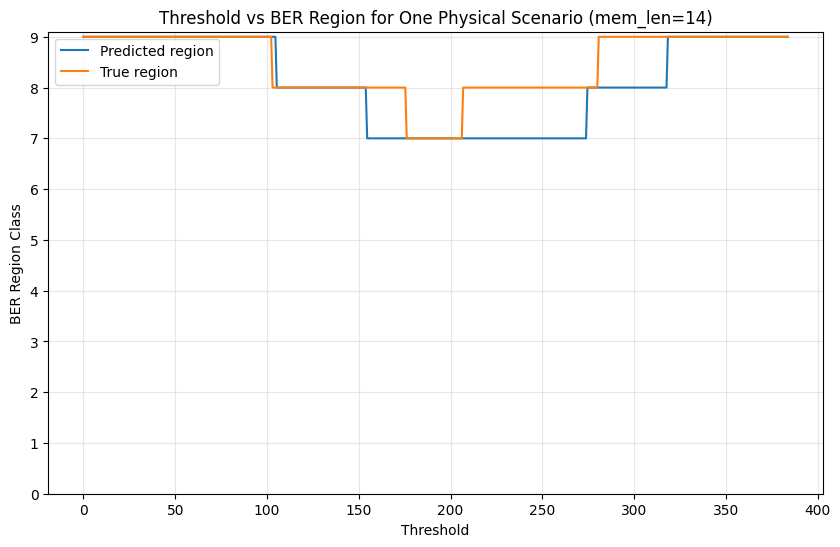

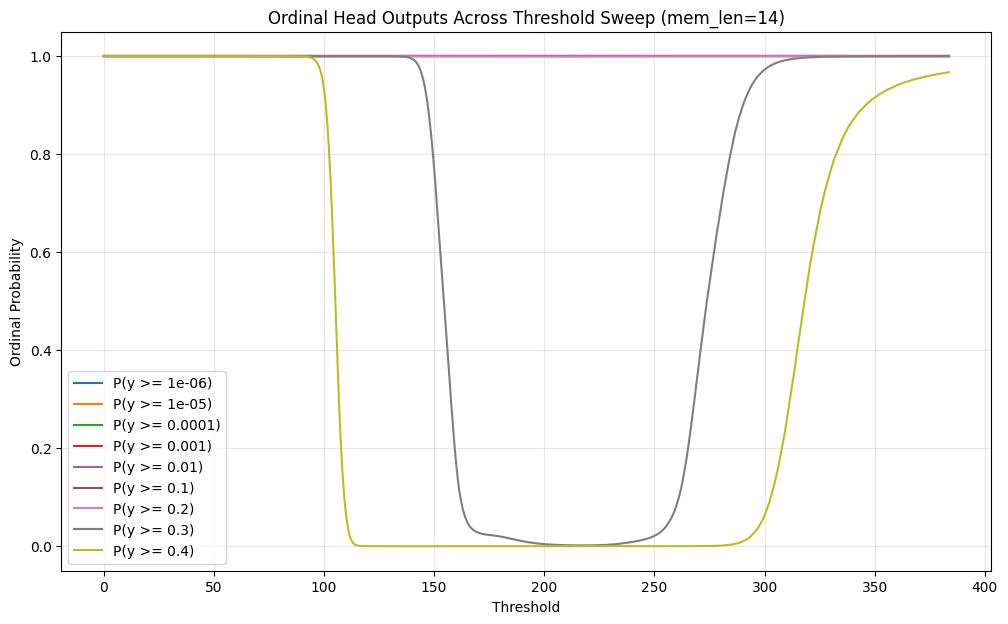

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "combined_random_physics_fulltrain_best_v1_multitask.pth"
SCALER_PATH = "combined_random_physics_fulltrain_scalers_v1_multitask.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# 10 ordered BER regions -> 9 ordinal thresholds
ORDINAL_THRESHOLDS = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.2, 0.3, 0.4]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1

REGION_LABELS = {
    0: "y < 1e-6",
    1: "1e-6 <= y < 1e-5",
    2: "1e-5 <= y < 1e-4",
    3: "1e-4 <= y < 1e-3",
    4: "1e-3 <= y < 1e-2",
    5: "1e-2 <= y < 1e-1",
    6: "0.1 <= y < 0.2",
    7: "0.2 <= y < 0.3",
    8: "0.3 <= y < 0.4",
    9: "0.4 <= y <= 0.5",
}

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    labels = np.full_like(y, 9, dtype=np.int64)

    labels[y < 0.4] = 8
    labels[y < 0.3] = 7
    labels[y < 0.2] = 6
    labels[y < 1e-1] = 5
    labels[y < 1e-2] = 4
    labels[y < 1e-3] = 3
    labels[y < 1e-4] = 2
    labels[y < 1e-5] = 1
    labels[y < 1e-6] = 0
    return labels


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.15, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.15, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.08, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.15):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.15,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalfMultiTask.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)
        return pred_raw_unconstrained, ord_logits


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)
real_regions = raw_to_region_labels_np(real_bers)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalfMultiTask(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.15,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
    num_ordinal_thresholds=len(scalers.get("ordinal_thresholds", ORDINAL_THRESHOLDS)),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out, ord_logits = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_regions = ordinal_logits_to_region_labels_torch(ord_logits).cpu().numpy().reshape(-1)
    pred_region_probs = torch.sigmoid(ord_logits).cpu().numpy()

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "real_region": real_regions,
    "predicted_region": pred_regions,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
    "region_abs_error": np.abs(pred_regions - real_regions),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error        :", results["abs_error"].mean())
print("Mean abs log10 error      :", results["abs_log10_error"].mean())
print("Max  abs log10 error      :", results["abs_log10_error"].max())
print("Mean region abs error     :", results["region_abs_error"].mean())
print("Exact region accuracy     :", np.mean(results["real_region"] == results["predicted_region"]))

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Real BER region there             :", REGION_LABELS[int(real_regions[best_real_idx])])

print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])
print("Predicted BER region there        :", REGION_LABELS[int(pred_regions[best_est_idx])])

# =========================
# Plot 1: log-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (log scale) for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# =========================
# Plot 2: linear-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (linear scale) for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# =========================
# Plot 3: predicted vs true region
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["predicted_region"], label="Predicted region")
plt.plot(results["threshold"], results["real_region"], label="True region")
plt.xlabel("Threshold")
plt.ylabel("BER Region Class")
plt.title(f"Threshold vs BER Region for One Physical Scenario (mem_len={case['mem_len']})")
plt.yticks(list(REGION_LABELS.keys()))
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# =========================
# Plot 4: ordinal threshold probabilities
# =========================
plt.figure(figsize=(12, 7))
for i, thr in enumerate(ORDINAL_THRESHOLDS):
    plt.plot(thresholds, pred_region_probs[:, i], label=f"P(y >= {thr:g})")
plt.xlabel("Threshold")
plt.ylabel("Ordinal Probability")
plt.title(f"Ordinal Head Outputs Across Threshold Sweep (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [3]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"

DATA_PATHS = [
    os.path.join(BASE_DIR, "data_random_with_random_variances_total_v2.csv"),
    os.path.join(BASE_DIR, "data_physics_with_variances_total.csv"),
]

NROWS_PER_DATASET = 2_500_000

# Continue training from existing multitask checkpoint
CONTINUE_TRAINING = True
INIT_MODEL_PATH = os.path.join(
    BASE_DIR, "combined_random_physics_fulltrain_best_v1_multitask.pth"
)

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "combined_random_physics_balanced_continue_best_v1_multitask.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "combined_random_physics_balanced_continue_last_v1_multitask.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "combined_random_physics_balanced_continue_scalers_v1_multitask.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# 10 ordered BER regions -> 9 ordinal thresholds
ORDINAL_THRESHOLDS = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.2, 0.3, 0.4]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1

REGION_NAMES = {
    0: "y < 1e-6",
    1: "1e-6 <= y < 1e-5",
    2: "1e-5 <= y < 1e-4",
    3: "1e-4 <= y < 1e-3",
    4: "1e-3 <= y < 1e-2",
    5: "1e-2 <= y < 1e-1",
    6: "0.1 <= y < 0.2",
    7: "0.2 <= y < 0.3",
    8: "0.3 <= y < 0.4",
    9: "0.4 <= y <= 0.5",
}


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


def validate_required_columns(df, file_path):
    if "mem_len" not in df.columns:
        raise ValueError(f"Required column 'mem_len' not found in {file_path}")
    if "N" not in df.columns:
        raise ValueError(f"Required column 'N' not found in {file_path}")

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError(f"No tap_* columns found in {file_path}")
    if not var_cols:
        raise ValueError(f"No var_* columns found in {file_path}")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch in {file_path}: "
            f"{len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {file_path}: {missing}")

    return tap_cols, var_cols


def load_and_merge_data(csv_paths, nrows_per_dataset):
    dfs = []
    reference_tap_cols = None
    reference_var_cols = None

    for path in csv_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Dataset not found: {path}")

        print(f"Loading up to {nrows_per_dataset:,} rows from: {path}")
        df = pd.read_csv(path, nrows=nrows_per_dataset)

        tap_cols, var_cols = validate_required_columns(df, path)

        if reference_tap_cols is None:
            reference_tap_cols = tap_cols
            reference_var_cols = var_cols
        else:
            if tap_cols != reference_tap_cols:
                raise ValueError(
                    f"tap columns do not match across files.\n"
                    f"Reference: {reference_tap_cols[:5]} ... total={len(reference_tap_cols)}\n"
                    f"Current ({path}): {tap_cols[:5]} ... total={len(tap_cols)}"
                )
            if var_cols != reference_var_cols:
                raise ValueError(
                    f"var columns do not match across files.\n"
                    f"Reference: {reference_var_cols[:5]} ... total={len(reference_var_cols)}\n"
                    f"Current ({path}): {var_cols[:5]} ... total={len(var_cols)}"
                )

        df["source_dataset"] = os.path.basename(path)
        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True)
    print(f"Combined rows before filtering: {len(merged):,}")

    return merged, reference_tap_cols, reference_var_cols


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    labels = np.full_like(y, 9, dtype=np.int64)

    labels[y < 0.4] = 8
    labels[y < 0.3] = 7
    labels[y < 0.2] = 6
    labels[y < 1e-1] = 5
    labels[y < 1e-2] = 4
    labels[y < 1e-3] = 3
    labels[y < 1e-4] = 2
    labels[y < 1e-5] = 1
    labels[y < 1e-6] = 0
    return labels


def region_labels_to_ordinal_targets_np(labels, num_thresholds=NUM_ORDINAL_THRESHOLDS):
    labels = np.asarray(labels).reshape(-1)
    thresholds = np.arange(1, num_thresholds + 1, dtype=np.int64)
    ordinal = (labels[:, None] >= thresholds[None, :]).astype(np.float32)
    return ordinal


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


def compute_region_class_weights(labels_np, num_classes=NUM_REGION_CLASSES, max_weight=8.0):
    counts = np.bincount(labels_np.reshape(-1), minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (num_classes * counts)
    weights = np.sqrt(weights)
    weights = np.clip(weights, 1.0, max_weight)
    return weights.astype(np.float32)


def compute_ordinal_pos_weights_from_region_labels(
    region_labels_np,
    num_thresholds=NUM_ORDINAL_THRESHOLDS,
    max_weight=20.0
):
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels_np, num_thresholds)
    pos_counts = ordinal_targets.sum(axis=0)
    neg_counts = ordinal_targets.shape[0] - pos_counts
    pos_counts = np.maximum(pos_counts, 1.0)
    pos_weight = neg_counts / pos_counts
    pos_weight = np.clip(pos_weight, 1.0, max_weight)
    return pos_weight.astype(np.float32)


# =========================
# Losses
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    def __init__(
        self,
        log_delta=0.35,
        raw_delta=0.006,
        alpha_log=0.70,
        beta_raw=0.30,
        use_regime_weights=False,
        low_thr=1e-4,
        mid_thr=1e-2,
        w_low=2.0,
        w_mid=2.5,
        w_high=1.75,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw

        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_high)
            weights = torch.where(
                target_raw < self.mid_thr,
                torch.full_like(weights, self.w_mid),
                weights
            )
            weights = torch.where(
                target_raw < self.low_thr,
                torch.full_like(weights, self.w_low),
                weights
            )
            total = total * weights

        return total.mean()


class OrdinalBCELoss(nn.Module):
    def __init__(self, pos_weight=None, reduction="mean"):
        super().__init__()
        if pos_weight is not None and not isinstance(pos_weight, torch.Tensor):
            pos_weight = torch.tensor(pos_weight, dtype=torch.float32)
        self.register_buffer("pos_weight", pos_weight if pos_weight is not None else None)
        self.reduction = reduction

    def forward(self, logits, ordinal_targets):
        return F.binary_cross_entropy_with_logits(
            logits,
            ordinal_targets,
            pos_weight=self.pos_weight,
            reduction=self.reduction
        )


class MultiTaskBERLoss(nn.Module):
    def __init__(self, reg_loss, ord_loss, lambda_ord=0.12):
        super().__init__()
        self.reg_loss = reg_loss
        self.ord_loss = ord_loss
        self.lambda_ord = lambda_ord

    def forward(self, pred_raw_unconstrained, ord_logits, target_log, target_ord):
        reg = self.reg_loss(pred_raw_unconstrained, target_log)
        ordl = self.ord_loss(ord_logits, target_ord)
        total = reg + self.lambda_ord * ordl
        return total, reg.detach(), ordl.detach()


# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.15, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.15, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.08, se=True
            )
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.15):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.15,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0],
            num_attn_heads=stage_pool_heads[0],
            attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1],
            num_attn_heads=stage_pool_heads[1],
            attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[2],
            attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2],
            num_attn_heads=stage_pool_heads[3],
            attn_dim=128
        )

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)

        return pred_raw_unconstrained, ord_logits


# =========================
# Data
# =========================
def prepare_data(csv_paths, batch_size=256, nrows_per_dataset=2_500_000, num_workers=0):
    df, tap_cols, var_cols = load_and_merge_data(csv_paths, nrows_per_dataset)

    df = df[df["mem_len"] != 1].copy()

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    print(f"Rows after cleaning/filtering: {len(df):,}")

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    region_labels = raw_to_region_labels_np(y_raw)
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log,
        t_region, temp_region,
        t_ord, temp_ord
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, harmonic_minus_gap_raw,
        X_thr, y_log, region_labels, ordinal_targets,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log,
        v_region, te_region,
        v_ord, te_ord
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_hmg_raw,
        temp_thr, temp_y_log, temp_region, temp_ord,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]

        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)

        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0

        seq = np.stack(
            [
                taps_scaled,
                vars_scaled,
                pos_ch,
                abs_scaled,
                snr_scaled,
                first_flag,
            ],
            axis=1
        ).astype(np.float32)

        return seq

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, hmg_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log.astype(np.float32)),
        torch.from_numpy(t_ord.astype(np.float32)),
        torch.from_numpy(t_region.astype(np.int64)),
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log.astype(np.float32)),
        torch.from_numpy(v_ord.astype(np.float32)),
        torch.from_numpy(v_region.astype(np.int64)),
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log.astype(np.float32)),
        torch.from_numpy(te_ord.astype(np.float32)),
        torch.from_numpy(te_region.astype(np.int64)),
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers
    )

    class_weights = compute_region_class_weights(t_region, NUM_REGION_CLASSES)
    ordinal_pos_weights = compute_ordinal_pos_weights_from_region_labels(
        t_region,
        num_thresholds=NUM_ORDINAL_THRESHOLDS,
        max_weight=20.0
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 3,
        "seq_feature_order": [
            "tap_scaled_mean",
            "variance",
            "pos",
            "abs_tap_scaled_mean",
            "snr_proxy_log",
            "first_flag",
        ],
        "global_feature_order": [
            "z0_margin",
            "z1_margin",
            "harmonic_minus_gap",
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "ordinal_thresholds": ORDINAL_THRESHOLDS,
        "num_region_classes": NUM_REGION_CLASSES,
        "class_weights": class_weights.tolist(),
        "ordinal_pos_weights": ordinal_pos_weights.tolist(),
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
        "data_paths": csv_paths,
        "nrows_per_dataset": nrows_per_dataset,
    }

    aux_info = {
        "class_weights": class_weights,
        "ordinal_pos_weights": ordinal_pos_weights,
    }

    return train_loader, val_loader, test_loader, scalers, aux_info, len(tap_cols)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_reg_loss = 0.0
    total_ord_loss = 0.0

    all_preds_log = []
    all_targets_log = []
    all_pred_regions = []
    all_true_regions = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log, b_ord, b_region in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)
            b_region = b_region.to(device, non_blocking=True)

            pred_raw_unconstrained, ord_logits = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during evaluation.")
            if has_nonfinite_tensor(ord_logits):
                raise RuntimeError("Non-finite ordinal logits detected during evaluation.")

            loss, reg_loss, ord_loss = criterion(
                pred_raw_unconstrained, ord_logits, b_y_log, b_ord
            )

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            pred_region = ordinal_logits_to_region_labels_torch(ord_logits)

            total_loss += loss.item()
            total_reg_loss += reg_loss.item()
            total_ord_loss += ord_loss.item()

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())
            all_pred_regions.append(pred_region.cpu().numpy())
            all_true_regions.append(b_region.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    avg_reg_loss = total_reg_loss / max(len(loader), 1)
    avg_ord_loss = total_ord_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    pred_regions = np.concatenate(all_pred_regions).reshape(-1)
    true_regions = np.concatenate(all_true_regions).reshape(-1)

    region_acc = float(np.mean(pred_regions == true_regions))
    region_mae = float(np.mean(np.abs(pred_regions - true_regions)))

    return {
        "loss": avg_loss,
        "reg_loss": avg_reg_loss,
        "ord_loss": avg_ord_loss,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "factor_error": factor_error,
        "rmse_raw": rmse_raw,
        "mae_raw": mae_raw,
        "region_acc": region_acc,
        "region_mae": region_mae,
    }


def evaluate_by_region_regression(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log, _, _ in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained, _ = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError(
                    "Non-finite prediction detected during per-region regression evaluation."
                )

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    region_masks = {
        "class=0 (y < 1e-6)": targets_raw < 1e-6,
        "class=1 (1e-6 <= y < 1e-5)": (targets_raw >= 1e-6) & (targets_raw < 1e-5),
        "class=2 (1e-5 <= y < 1e-4)": (targets_raw >= 1e-5) & (targets_raw < 1e-4),
        "class=3 (1e-4 <= y < 1e-3)": (targets_raw >= 1e-4) & (targets_raw < 1e-3),
        "class=4 (1e-3 <= y < 1e-2)": (targets_raw >= 1e-3) & (targets_raw < 1e-2),
        "class=5 (1e-2 <= y < 1e-1)": (targets_raw >= 1e-2) & (targets_raw < 1e-1),
        "class=6 (0.1 <= y < 0.2)": (targets_raw >= 0.1) & (targets_raw < 0.2),
        "class=7 (0.2 <= y < 0.3)": (targets_raw >= 0.2) & (targets_raw < 0.3),
        "class=8 (0.3 <= y < 0.4)": (targets_raw >= 0.3) & (targets_raw < 0.4),
        "class=9 (0.4 <= y <= 0.5)": (targets_raw >= 0.4) & (targets_raw <= 0.5),
    }

    metrics = {}
    for name, mask in region_masks.items():
        if np.any(mask):
            rmse_log = float(
                np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2))
            )
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(
                np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2))
            )
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None

    return metrics


def evaluate_by_region_class(model, loader, device):
    model.eval()
    all_pred_regions = []
    all_true_regions = []

    with torch.no_grad():
        for b_seq, b_global, b_thr, _, _, b_region in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            _, ord_logits = model(b_seq, b_global, b_thr)
            pred_region = ordinal_logits_to_region_labels_torch(ord_logits)

            all_pred_regions.append(pred_region.cpu().numpy())
            all_true_regions.append(b_region.numpy())

    pred_regions = np.concatenate(all_pred_regions).reshape(-1)
    true_regions = np.concatenate(all_true_regions).reshape(-1)

    results = {}
    for cls in range(NUM_REGION_CLASSES):
        mask = (true_regions == cls)
        if np.any(mask):
            acc = float(np.mean(pred_regions[mask] == true_regions[mask]))
            mae = float(np.mean(np.abs(pred_regions[mask] - true_regions[mask])))
            results[cls] = {
                "count": int(mask.sum()),
                "acc": acc,
                "ordinal_abs_error": mae,
            }
        else:
            results[cls] = None

    return results


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, aux_info, seq_len = prepare_data(
        DATA_PATHS,
        batch_size=256,
        nrows_per_dataset=NROWS_PER_DATASET,
        num_workers=0
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)
    print(f"Scalers saved to: {SCALER_SAVE_PATH}")

    model = BERMultiScaleResCNNBoundedLogHalfMultiTask(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.15,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ).to(device)

    if CONTINUE_TRAINING and os.path.exists(INIT_MODEL_PATH):
        print(f"Continuing training from checkpoint: {INIT_MODEL_PATH}")
        model.load_state_dict(torch.load(INIT_MODEL_PATH, map_location=device))
        optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
    else:
        print("Checkpoint not found; training from scratch.")
        optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    reg_loss = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.35,
        raw_delta=0.006,
        alpha_log=0.70,
        beta_raw=0.30,
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        w_low=2.0,
        w_mid=2.5,
        w_high=1.75,
    )

    ord_loss = OrdinalBCELoss(
        pos_weight=torch.tensor(
            aux_info["ordinal_pos_weights"], dtype=torch.float32, device=device
        ),
        reduction="mean"
    )

    criterion = MultiTaskBERLoss(
        reg_loss=reg_loss,
        ord_loss=ord_loss,
        lambda_ord=0.12
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 10
    wait = 0
    min_epochs_before_early_stop = 20
    max_epochs = 50

    print(f"Detected sequence length L = {seq_len}")
    print(f"Ordinal thresholds: {ORDINAL_THRESHOLDS}")
    print(f"Ordinal pos weights: {aux_info['ordinal_pos_weights']}")
    print("Using BALANCED continuation setup:")
    print("  alpha_log=0.70, beta_raw=0.30")
    print("  w_low=2.0, w_mid=2.5, w_high=1.75")
    print("  lambda_ord=0.12")
    print("  max_epochs=50")

    training_broke = False

    for epoch in range(max_epochs):
        model.train()

        for batch_idx, (b_seq, b_global, b_thr, b_y_log, b_ord, _) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained, ord_logits = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            if has_nonfinite_tensor(ord_logits):
                print(
                    f"Non-finite ordinal logits detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss, reg_part, ord_part = criterion(
                pred_raw_unconstrained, ord_logits, b_y_log, b_ord
            )

            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, "
                    f"batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad
                    and param.data is not None
                    and not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_metrics = evaluate(model, train_loader, criterion, device)
            val_metrics = evaluate(model, val_loader, criterion, device)
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_metrics["loss"])
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Train Reg: {train_metrics['reg_loss']:.4f} | "
            f"Val Reg: {val_metrics['reg_loss']:.4f} | "
            f"Train Ord: {train_metrics['ord_loss']:.4f} | "
            f"Val Ord: {val_metrics['ord_loss']:.4f} | "
            f"Train RMSE(log10): {train_metrics['rmse_log']:.4f} (~{train_metrics['factor_error']:.2f}x) | "
            f"Val RMSE(log10): {val_metrics['rmse_log']:.4f} (~{val_metrics['factor_error']:.2f}x) | "
            f"Train RMSE(raw): {train_metrics['rmse_raw']:.6f} | "
            f"Val RMSE(raw): {val_metrics['rmse_raw']:.6f} | "
            f"Train Region Acc: {train_metrics['region_acc']:.4f} | "
            f"Val Region Acc: {val_metrics['region_acc']:.4f} | "
            f"Train Region MAE: {train_metrics['region_mae']:.4f} | "
            f"Val Region MAE: {val_metrics['region_mae']:.4f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_metrics['loss']:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_metrics = evaluate(model, test_loader, criterion, device)

    print(
        f"Test Loss: {test_metrics['loss']:.4f} | "
        f"Test Reg Loss: {test_metrics['reg_loss']:.4f} | "
        f"Test Ord Loss: {test_metrics['ord_loss']:.4f} | "
        f"Test RMSE(log10): {test_metrics['rmse_log']:.4f} | "
        f"Test MAE(log10): {test_metrics['mae_log']:.4f} | "
        f"Typical multiplicative error: ~{test_metrics['factor_error']:.2f}x | "
        f"Test RMSE(raw): {test_metrics['rmse_raw']:.6f} | "
        f"Test MAE(raw): {test_metrics['mae_raw']:.6f} | "
        f"Test Region Acc: {test_metrics['region_acc']:.4f} | "
        f"Test Region MAE: {test_metrics['region_mae']:.4f}"
    )

    region_reg_metrics = evaluate_by_region_regression(model, test_loader, device)
    print("\nPer-region regression diagnostics:")
    for name, stats in region_reg_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    region_metrics = evaluate_by_region_class(model, test_loader, device)
    print("\nPer-region ordinal diagnostics:")
    for cls, stats in region_metrics.items():
        if stats is None:
            print(f"class={cls} ({REGION_NAMES[cls]}): no samples")
        else:
            print(
                f"class={cls} ({REGION_NAMES[cls]}) | "
                f"count={stats['count']} | "
                f"acc={stats['acc']:.4f} | "
                f"ordinal_abs_error={stats['ordinal_abs_error']:.4f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    missing = [p for p in DATA_PATHS if not os.path.exists(p)]
    if missing:
        print("Critical Error: Missing dataset files:")
        for p in missing:
            print(f"  - {p}")
    else:
        print("Using combined training from both datasets:")
        for p in DATA_PATHS:
            print(f"  - {p}")
        print(f"Row cap per dataset: {NROWS_PER_DATASET:,}")

        trained_model = train_engine()

Using combined training from both datasets:
  - ./data_random_with_random_variances_total_v2.csv
  - ./data_physics_with_variances_total.csv
Row cap per dataset: 2,500,000
Executing on: cuda
Loading up to 2,500,000 rows from: ./data_random_with_random_variances_total_v2.csv
Loading up to 2,500,000 rows from: ./data_physics_with_variances_total.csv
Combined rows before filtering: 5,000,000
Rows after cleaning/filtering: 4,109,558
Scalers saved to: ./combined_random_physics_balanced_continue_scalers_v1_multitask.pkl
Continuing training from checkpoint: ./combined_random_physics_fulltrain_best_v1_multitask.pth
Detected sequence length L = 14
Ordinal thresholds: [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4]
Ordinal pos weights: [1.        1.        1.        1.        1.        1.        1.
 1.2780503 2.7728765]
Using BALANCED continuation setup:
  alpha_log=0.70, beta_raw=0.30
  w_low=2.0, w_mid=2.5, w_high=1.75
  lambda_ord=0.12
  max_epochs=50
Epoch 001 | LR: 1.00e-05 | Train 

Epoch 020 | LR: 5.00e-06 | Train Loss: 0.0087 | Val Loss: 0.0091 | Train Reg: 0.0072 | Val Reg: 0.0075 | Train Ord: 0.0129 | Val Ord: 0.0135 | Train RMSE(log10): 0.1405 (~1.38x) | Val RMSE(log10): 0.1535 (~1.42x) | Train RMSE(raw): 0.031975 | Val RMSE(raw): 0.032025 | Train Region Acc: 0.9559 | Val Region Acc: 0.9546 | Train Region MAE: 0.0447 | Val Region MAE: 0.0461
Epoch 021 | LR: 5.00e-06 | Train Loss: 0.0129 | Val Loss: 0.0132 | Train Reg: 0.0106 | Val Reg: 0.0109 | Train Ord: 0.0185 | Val Ord: 0.0190 | Train RMSE(log10): 0.1708 (~1.48x) | Val RMSE(log10): 0.1815 (~1.52x) | Train RMSE(raw): 0.031400 | Val RMSE(raw): 0.031443 | Train Region Acc: 0.9430 | Val Region Acc: 0.9421 | Train Region MAE: 0.0578 | Val Region MAE: 0.0589
Epoch 022 | LR: 5.00e-06 | Train Loss: 0.0073 | Val Loss: 0.0076 | Train Reg: 0.0059 | Val Reg: 0.0061 | Train Ord: 0.0116 | Val Ord: 0.0121 | Train RMSE(log10): 0.1343 (~1.36x) | Val RMSE(log10): 0.1449 (~1.40x) | Train RMSE(raw): 0.031839 | Val RMSE(raw): 


Per-region ordinal diagnostics:
class=0 (y < 1e-6) | count=50547 | acc=0.9917 | ordinal_abs_error=0.0098
class=1 (1e-6 <= y < 1e-5) | count=2336 | acc=0.7573 | ordinal_abs_error=0.2526
class=2 (1e-5 <= y < 1e-4) | count=2696 | acc=0.8045 | ordinal_abs_error=0.2033
class=3 (1e-4 <= y < 1e-3) | count=3700 | acc=0.8578 | ordinal_abs_error=0.1508
class=4 (1e-3 <= y < 1e-2) | count=6406 | acc=0.9115 | ordinal_abs_error=0.0933
class=5 (1e-2 <= y < 1e-1) | count=51996 | acc=0.9612 | ordinal_abs_error=0.0393
class=6 (0.1 <= y < 0.2) | count=105575 | acc=0.9601 | ordinal_abs_error=0.0400
class=7 (0.2 <= y < 0.3) | count=122937 | acc=0.9476 | ordinal_abs_error=0.0524
class=8 (0.3 <= y < 0.4) | count=106856 | acc=0.9365 | ordinal_abs_error=0.0635
class=9 (0.4 <= y <= 0.5) | count=163385 | acc=0.9986 | ordinal_abs_error=0.0014


Generated physical scenario
radius    = 4.999903475776163
distance  = 13.063595613360427
diffusion = 63.15707394395149
Ts        = 0.5834416162676823
N         = 2026
mem_len   = 14
P         = [0.03545102 0.042582   0.02704795 0.01857409 0.01368091 0.01059455
 0.00850978 0.00702648 0.00592783 0.00508774 0.00442855 0.00390015
 0.00346895 0.00311165]
P_scaled  = [71.82377081 86.27113641 54.79914164 37.63111579 27.71752004 21.46456524
 17.24082032 14.23564842 12.00979138 10.30776824  8.9722469   7.90171201
  7.0280834   6.304198  ]
variances = [69.27754472 82.59753869 53.31693734 36.93215188 27.33831919 21.23715776
 17.09410468 14.13562193 11.93859933 10.25532496  8.93251283  7.87089412
  7.00370336  6.28458156]
Threshold search interval: 0.0 to 383.7075186062634
sum(P_scaled) = 383.7075186062634
    threshold  real_BER  estimated_BER  real_region  predicted_region  \
0    0.000000  0.499999       0.476592            9                 9   
1    0.768953  0.499937       0.489123          

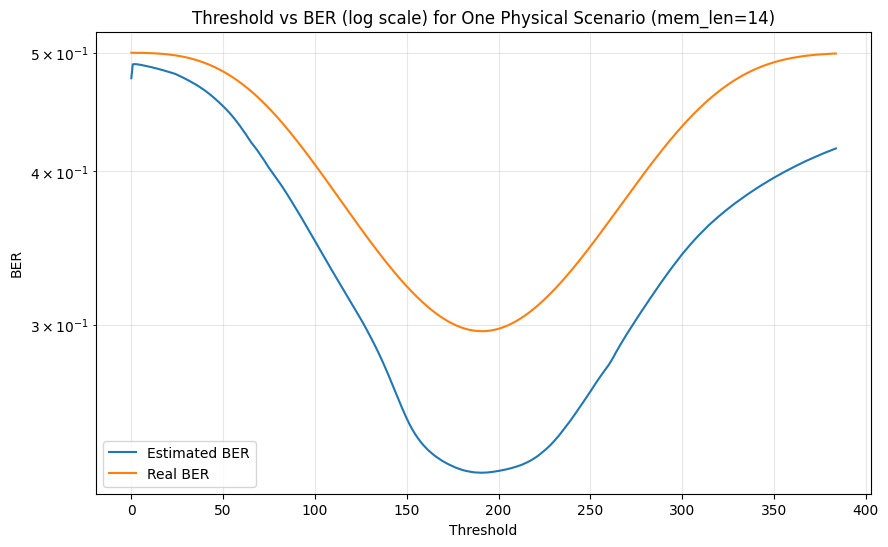

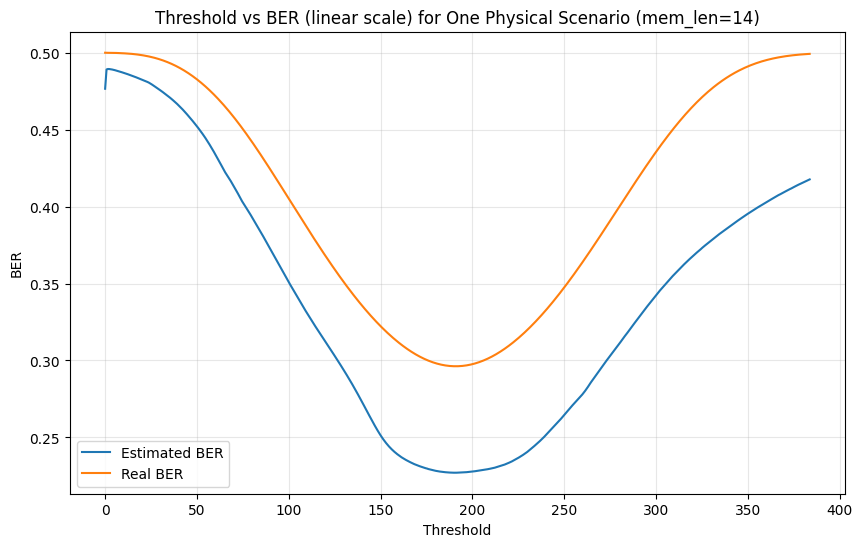

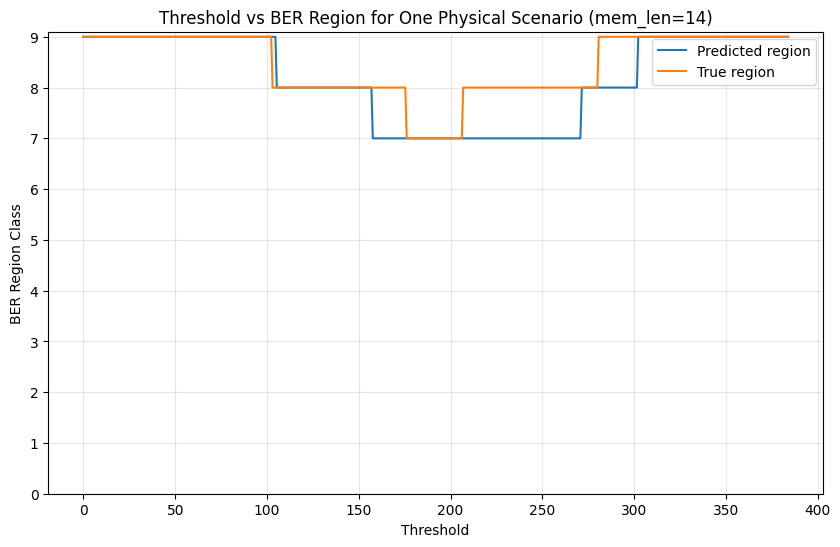

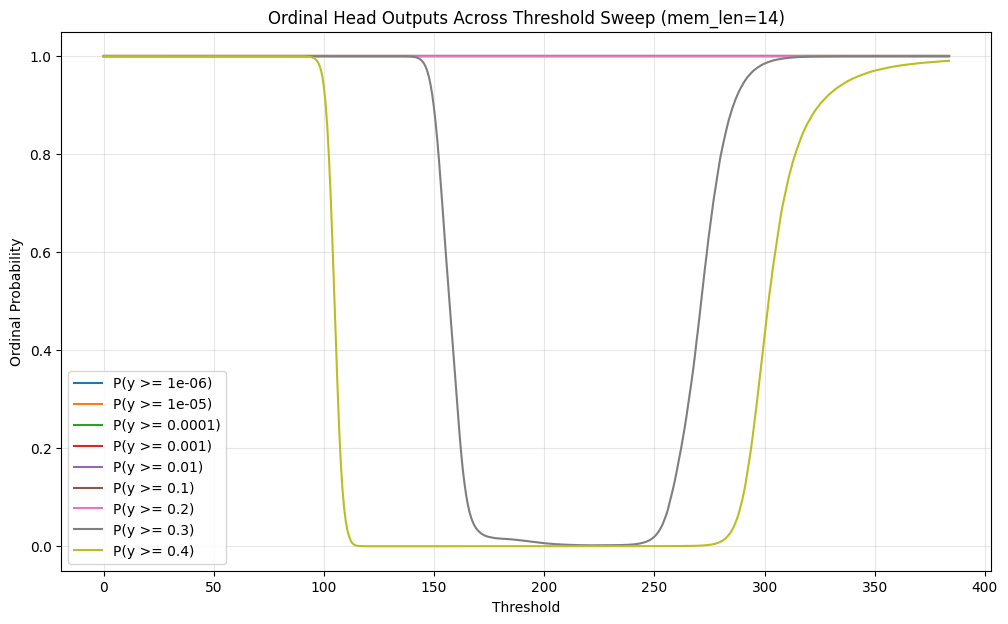

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "combined_random_physics_balanced_continue_best_v1_multitask.pth"
SCALER_PATH = "combined_random_physics_balanced_continue_scalers_v1_multitask.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# 10 ordered BER regions -> 9 ordinal thresholds
ORDINAL_THRESHOLDS = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.2, 0.3, 0.4]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1

REGION_LABELS = {
    0: "y < 1e-6",
    1: "1e-6 <= y < 1e-5",
    2: "1e-5 <= y < 1e-4",
    3: "1e-4 <= y < 1e-3",
    4: "1e-3 <= y < 1e-2",
    5: "1e-2 <= y < 1e-1",
    6: "0.1 <= y < 0.2",
    7: "0.2 <= y < 0.3",
    8: "0.3 <= y < 0.4",
    9: "0.4 <= y <= 0.5",
}

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))


def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P


def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))


def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    labels = np.full_like(y, 9, dtype=np.int64)

    labels[y < 0.4] = 8
    labels[y < 0.3] = 7
    labels[y < 0.2] = 6
    labels[y < 1e-1] = 5
    labels[y < 1e-2] = 4
    labels[y < 1e-3] = 3
    labels[y < 1e-4] = 2
    labels[y < 1e-5] = 1
    labels[y < 1e-6] = 0
    return labels


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


# =========================
# One physical scenario
# =========================
def generate_physical_case(
    rng,
    min_mem_len=10,
    max_mem_len=14,
    arrival_coverage=0.70,
    max_tries=5000
):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries."
    )


# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch,
                out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)


class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.15, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )

        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out


class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.15, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch,
                out_ch,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x


class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.08, se=True)
        )

    def forward(self, x):
        return self.net(x)


class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.15):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)


class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled


class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)


class BERMultiScaleResCNNBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=3,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.15,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2],
                num_heads=attn_heads,
                mlp_ratio=2.0,
                dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            cond_dim
        )

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalfMultiTask.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)
        return pred_raw_unconstrained, ord_logits


# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)


def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(
        harmonic_minus_gap_raw
    ).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [
            taps_scaled,
            vars_scaled,
            pos_ch,
            abs_scaled,
            snr_scaled,
            first_flag,
        ],
        axis=1
    ).astype(np.float32)

    global_feats = np.concatenate(
        [z0_scaled, z1_scaled, harmonic_minus_gap_scaled],
        axis=1
    ).astype(np.float32)

    return seq, global_feats, thr_scaled


# =========================
# Generate one physical scenario
# =========================
rng = np.random.default_rng(RANDOM_SEED)
case = generate_physical_case(
    rng,
    min_mem_len=PHYSICS_MIN_MEM_LEN,
    max_mem_len=PHYSICS_MAX_MEM_LEN,
    arrival_coverage=ARRIVAL_COVERAGE
)

print("Generated physical scenario")
print("radius    =", case["radius"])
print("distance  =", case["distance"])
print("diffusion =", case["diffusion"])
print("Ts        =", case["Ts"])
print("N         =", case["N"])
print("mem_len   =", case["mem_len"])
print("P         =", case["P"])
print("P_scaled  =", case["P_scaled"])
print("variances =", case["variances"])

# =========================
# Threshold sweep
# =========================
thr_min = 0.0
thr_max = float(np.sum(case["P_scaled"]))
thresholds = np.linspace(thr_min, thr_max, N_THRESHOLDS)

print("Threshold search interval:", thr_min, "to", thr_max)
print("sum(P_scaled) =", np.sum(case["P_scaled"]))

real_bers = np.array([
    calculate_ber_vectorized(
        mem_len=case["mem_len"],
        threshold=thr,
        P_scaled=case["P_scaled"],
        variances=case["variances"]
    )
    for thr in thresholds
])

real_bers = np.clip(real_bers, EPS, 0.5)
real_regions = raw_to_region_labels_np(real_bers)

# =========================
# Load model + scalers
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scalers = joblib.load(SCALER_PATH)

seq_len = scalers["seq_len"]
model = BERMultiScaleResCNNBoundedLogHalfMultiTask(
    seq_len=seq_len,
    threshold_dim=1,
    global_dim=scalers.get("global_dim", 3),
    stem_ch=32,
    channels=(64, 96, 128),
    dropout=0.15,
    stage_pool_heads=(2, 2, 2, 4),
    attn_heads=4,
    pos_emb_dim=scalers.get("pos_emb_dim", 8),
    use_self_attention=scalers.get("uses_self_attention", True),
    num_ordinal_thresholds=len(scalers.get("ordinal_thresholds", ORDINAL_THRESHOLDS)),
).to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

# =========================
# Predict across thresholds
# =========================
sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)

seq_t = torch.from_numpy(seq).to(device)
global_t = torch.from_numpy(global_feats).to(device)
thr_t = torch.from_numpy(thr_scaled).to(device)

with torch.no_grad():
    pred_raw_out, ord_logits = model(seq_t, global_t, thr_t)
    pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_log = model.raw_to_log10ber(pred_raw_out).cpu().numpy().reshape(-1)
    pred_regions = ordinal_logits_to_region_labels_torch(ord_logits).cpu().numpy().reshape(-1)
    pred_region_probs = torch.sigmoid(ord_logits).cpu().numpy()

pred_bers = np.clip(pred_bers, EPS, 0.5)

# =========================
# Comparison table
# =========================
results = pd.DataFrame({
    "threshold": thresholds,
    "real_BER": real_bers,
    "estimated_BER": pred_bers,
    "real_region": real_regions,
    "predicted_region": pred_regions,
    "abs_error": np.abs(pred_bers - real_bers),
    "abs_log10_error": np.abs(
        np.log10(np.clip(pred_bers, EPS, 0.5)) -
        np.log10(np.clip(real_bers, EPS, 0.5))
    ),
    "region_abs_error": np.abs(pred_regions - real_regions),
})

print(results.head(15))

print("\nSummary")
print("Mean abs raw error        :", results["abs_error"].mean())
print("Mean abs log10 error      :", results["abs_log10_error"].mean())
print("Max  abs log10 error      :", results["abs_log10_error"].max())
print("Mean region abs error     :", results["region_abs_error"].mean())
print("Exact region accuracy     :", np.mean(results["real_region"] == results["predicted_region"]))

best_real_idx = np.argmin(real_bers)
best_est_idx = np.argmin(pred_bers)

print("\nBest threshold from real BER      :", thresholds[best_real_idx])
print("Minimum real BER                  :", real_bers[best_real_idx])
print("Real BER region there             :", REGION_LABELS[int(real_regions[best_real_idx])])

print("Best threshold from estimated BER :", thresholds[best_est_idx])
print("Estimated BER at that threshold   :", pred_bers[best_est_idx])
print("Predicted BER region there        :", REGION_LABELS[int(pred_regions[best_est_idx])])

# =========================
# Plot 1: log-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (log scale) for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# =========================
# Plot 2: linear-scale BER
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["estimated_BER"], label="Estimated BER")
plt.plot(results["threshold"], results["real_BER"], label="Real BER")
plt.yscale("linear")
plt.xlabel("Threshold")
plt.ylabel("BER")
plt.title(f"Threshold vs BER (linear scale) for One Physical Scenario (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# =========================
# Plot 3: predicted vs true region
# =========================
plt.figure(figsize=(10, 6))
plt.plot(results["threshold"], results["predicted_region"], label="Predicted region")
plt.plot(results["threshold"], results["real_region"], label="True region")
plt.xlabel("Threshold")
plt.ylabel("BER Region Class")
plt.title(f"Threshold vs BER Region for One Physical Scenario (mem_len={case['mem_len']})")
plt.yticks(list(REGION_LABELS.keys()))
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# =========================
# Plot 4: ordinal threshold probabilities
# =========================
plt.figure(figsize=(12, 7))
for i, thr in enumerate(ORDINAL_THRESHOLDS):
    plt.plot(thresholds, pred_region_probs[:, i], label=f"P(y >= {thr:g})")
plt.xlabel("Threshold")
plt.ylabel("Ordinal Probability")
plt.title(f"Ordinal Head Outputs Across Threshold Sweep (mem_len={case['mem_len']})")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [1]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"

DATA_PATHS = [
    os.path.join(BASE_DIR, "data_random_with_random_variances_total_v2.csv"),
]

NROWS_PER_DATASET = 5_000_000

BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "random_fulltrain_highber_best_v2_target020_040_transformer_multitask.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "random_fulltrain_highber_last_v2_target020_040_transformer_multitask.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "random_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl"
)

EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

ORDINAL_THRESHOLDS = [
    1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1,
    0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45
]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)
NUM_REGION_CLASSES = NUM_ORDINAL_THRESHOLDS + 1


# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]


def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)

    if len(edges) < 3:
        return None

    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins


def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()


def validate_required_columns(df, file_path):
    if "mem_len" not in df.columns:
        raise ValueError(f"Required column 'mem_len' not found in {file_path}")
    if "N" not in df.columns:
        raise ValueError(f"Required column 'N' not found in {file_path}")

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError(f"No tap_* columns found in {file_path}")
    if not var_cols:
        raise ValueError(f"No var_* columns found in {file_path}")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch in {file_path}: "
            f"{len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {file_path}: {missing}")

    return tap_cols, var_cols


def load_and_merge_data(csv_paths, nrows_per_dataset):
    dfs = []
    reference_tap_cols = None
    reference_var_cols = None

    for path in csv_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Dataset not found: {path}")

        print(f"Loading up to {nrows_per_dataset:,} rows from: {path}")
        df = pd.read_csv(path, nrows=nrows_per_dataset)

        tap_cols, var_cols = validate_required_columns(df, path)

        if reference_tap_cols is None:
            reference_tap_cols = tap_cols
            reference_var_cols = var_cols
        else:
            if tap_cols != reference_tap_cols:
                raise ValueError("tap columns do not match across files.")
            if var_cols != reference_var_cols:
                raise ValueError("var columns do not match across files.")

        df["source_dataset"] = os.path.basename(path)
        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True)
    print(f"Combined rows before filtering: {len(merged):,}")

    return merged, reference_tap_cols, reference_var_cols


def y_log_to_raw_np(y_log):
    return np.clip(10 ** y_log, EPS, 0.5)


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    labels = np.searchsorted(np.asarray(ORDINAL_THRESHOLDS), y, side="right")
    return labels.astype(np.int64)


def region_labels_to_ordinal_targets_np(labels, num_thresholds=NUM_ORDINAL_THRESHOLDS):
    labels = np.asarray(labels).reshape(-1)
    thresholds = np.arange(1, num_thresholds + 1, dtype=np.int64)
    ordinal = (labels[:, None] >= thresholds[None, :]).astype(np.float32)
    return ordinal


def ordinal_logits_to_region_labels_torch(logits):
    probs = torch.sigmoid(logits)
    passed = (probs >= 0.5).sum(dim=1)
    return passed.long()


def compute_region_class_weights(labels_np, num_classes=NUM_REGION_CLASSES, max_weight=8.0):
    counts = np.bincount(labels_np.reshape(-1), minlength=num_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (num_classes * counts)
    weights = np.sqrt(weights)
    weights = np.clip(weights, 1.0, max_weight)
    return weights.astype(np.float32)


def compute_ordinal_pos_weights_from_region_labels(
    region_labels_np,
    num_thresholds=NUM_ORDINAL_THRESHOLDS,
    max_weight=20.0,
):
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels_np, num_thresholds)
    pos_counts = ordinal_targets.sum(axis=0)
    neg_counts = ordinal_targets.shape[0] - pos_counts
    pos_counts = np.maximum(pos_counts, 1.0)
    pos_weight = neg_counts / pos_counts
    pos_weight = np.clip(pos_weight, 1.0, max_weight)
    return pos_weight.astype(np.float32)


# =========================
# Targeted Regression Loss
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    def __init__(
        self,
        log_delta=0.35,
        raw_delta=0.006,
        rel_delta=0.03,
        alpha_log=0.45,
        beta_raw=0.35,
        gamma_rel=0.20,
        use_regime_weights=True,
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.rel_delta = rel_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        self.gamma_rel = gamma_rel
        self.use_regime_weights = use_regime_weights

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta,
            0.5 * err * err,
            delta * (abs_err - 0.5 * delta),
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log,
            target_log_for_loss,
            self.log_delta,
        )

        raw_loss = self.huber_elementwise(
            pred_raw,
            target_raw,
            self.raw_delta,
        )

        rel_err = (pred_raw - target_raw) / torch.clamp(target_raw, min=1e-6)
        rel_loss = self.huber_elementwise(
            rel_err,
            torch.zeros_like(rel_err),
            self.rel_delta,
        )

        total = (
            self.alpha_log * log_loss
            + self.beta_raw * raw_loss
            + self.gamma_rel * rel_loss
        )

        if self.use_regime_weights:
            weights = torch.ones_like(target_raw)

            weights = torch.where(
                (target_raw >= 1e-2) & (target_raw < 0.1),
                torch.full_like(weights, 1.5),
                weights,
            )
            weights = torch.where(
                (target_raw >= 0.1) & (target_raw < 0.15),
                torch.full_like(weights, 2.5),
                weights,
            )
            weights = torch.where(
                (target_raw >= 0.15) & (target_raw < 0.2),
                torch.full_like(weights, 3.0),
                weights,
            )
            weights = torch.where(
                (target_raw >= 0.2) & (target_raw < 0.3),
                torch.full_like(weights, 4.0),
                weights,
            )
            weights = torch.where(
                (target_raw >= 0.3) & (target_raw < 0.4),
                torch.full_like(weights, 4.5),
                weights,
            )
            weights = torch.where(
                (target_raw >= 0.4) & (target_raw < 0.45),
                torch.full_like(weights, 3.0),
                weights,
            )
            weights = torch.where(
                target_raw >= 0.45,
                torch.full_like(weights, 2.5),
                weights,
            )

            total = total * weights

        return total.mean()


class OrdinalBCELoss(nn.Module):
    def __init__(self, pos_weight=None, reduction="mean"):
        super().__init__()
        if pos_weight is not None and not isinstance(pos_weight, torch.Tensor):
            pos_weight = torch.tensor(pos_weight, dtype=torch.float32)
        self.register_buffer("pos_weight", pos_weight if pos_weight is not None else None)
        self.reduction = reduction

    def forward(self, logits, ordinal_targets):
        return F.binary_cross_entropy_with_logits(
            logits,
            ordinal_targets,
            pos_weight=self.pos_weight,
            reduction=self.reduction,
        )


class MultiTaskBERLoss(nn.Module):
    def __init__(self, reg_loss, ord_loss, lambda_ord=0.25):
        super().__init__()
        self.reg_loss = reg_loss
        self.ord_loss = ord_loss
        self.lambda_ord = lambda_ord

    def forward(self, pred_raw_unconstrained, ord_logits, target_log, target_ord):
        reg = self.reg_loss(pred_raw_unconstrained, target_log)
        ordl = self.ord_loss(ord_logits, target_ord)
        total = reg + self.lambda_ord * ordl
        return total, reg.detach(), ordl.detach()


# =========================
# Set Transformer Blocks
# =========================
class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)

        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=-1)

        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)

        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=1)
        pooled = (weights * x).sum(dim=1)
        return pooled


# =========================
# Model
# =========================
class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.past_seq_len = past_seq_len
        self.token_dim = token_dim
        self.first_token_dim = first_token_dim
        self.d_model = d_model
        self.num_ordinal_thresholds = num_ordinal_thresholds

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
        )

        cond_dim = 32 + 64

        self.first_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim,
            feat_dim=d_model,
            hidden_dim=256,
        )
        self.set_cond_mod = ConditionalFeatureModulation(
            cond_dim=cond_dim,
            feat_dim=d_model,
            hidden_dim=256,
        )

        self.set_blocks = nn.ModuleList(
            [
                SetSelfAttentionBlock(
                    d_model=d_model,
                    num_heads=num_heads,
                    mlp_ratio=mlp_ratio,
                    dropout=dropout,
                )
                for _ in range(num_set_layers)
            ]
        )

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model=d_model, hidden_dim=128)

        set_summary_dim = 3 * d_model
        head_in = d_model + set_summary_dim + cond_dim

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds),
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5,
                device=pred_raw_unconstrained.device,
                dtype=pred_raw_unconstrained.dtype,
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold):
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)

        for block in self.set_blocks:
            set_x = block(set_x)

        set_x = self.final_set_norm(set_x)

        pooled_attn = self.set_attn_pool(set_x)
        pooled_mean = set_x.mean(dim=1)
        pooled_max = set_x.amax(dim=1)

        set_summary = torch.cat([pooled_attn, pooled_mean, pooled_max], dim=-1)
        fused = torch.cat([first_x, set_summary, cond], dim=-1)

        pred_raw_unconstrained = self.reg_head(fused)
        ord_logits = self.ord_head(fused)

        return pred_raw_unconstrained, ord_logits


# =========================
# Data
# =========================
def prepare_data(csv_paths, batch_size=256, nrows_per_dataset=2_500_000, num_workers=0):
    df, tap_cols, var_cols = load_and_merge_data(csv_paths, nrows_per_dataset)

    df = df[df["mem_len"] != 1].copy()

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    print(f"Rows after cleaning/filtering: {len(df):,}")

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values; cannot use them safely.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)

    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    region_labels = raw_to_region_labels_np(y_raw)
    ordinal_targets = region_labels_to_ordinal_targets_np(region_labels)

    strat_labels = make_strat_bins(y_log, n_bins=10)

    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_hmg_raw, temp_hmg_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log,
        t_region, temp_region,
        t_ord, temp_ord,
    ) = train_test_split(
        X_taps_feat,
        X_vars_feat,
        abs_taps_raw,
        snr_raw,
        z0_raw,
        z1_raw,
        harmonic_minus_gap_raw,
        X_thr,
        y_log,
        region_labels,
        ordinal_targets,
        **split_args,
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)

    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_hmg_raw, te_hmg_raw,
        v_thr, te_thr,
        v_y_log, te_y_log,
        v_region, te_region,
        v_ord, te_ord,
    ) = train_test_split(
        temp_taps_raw,
        temp_vars_raw,
        temp_abs_raw,
        temp_snr_raw,
        temp_z0_raw,
        temp_z1_raw,
        temp_hmg_raw,
        temp_thr,
        temp_y_log,
        temp_region,
        temp_ord,
        **split_args2,
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    if L < 2:
        raise ValueError("Need at least 2 taps so that index 0 and post-first set both exist.")

    def build_first_and_past_tokens(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        first_token = np.stack(
            [
                taps_scaled[:, 0],
                vars_scaled[:, 0],
                abs_scaled[:, 0],
                snr_scaled[:, 0],
            ],
            axis=1,
        ).astype(np.float32)

        past_tokens = np.stack(
            [
                taps_scaled[:, 1:],
                vars_scaled[:, 1:],
                abs_scaled[:, 1:],
                snr_scaled[:, 1:],
            ],
            axis=2,
        ).astype(np.float32)

        return first_token, past_tokens

    def build_global_features(z0_scaled, z1_scaled, hmg_scaled):
        return np.concatenate([z0_scaled, z1_scaled, hmg_scaled], axis=1).astype(np.float32)

    t_first, t_past = build_first_and_past_tokens(t_taps, t_vars, t_abs, t_snr)
    v_first, v_past = build_first_and_past_tokens(v_taps, v_vars, v_abs, v_snr)
    te_first, te_past = build_first_and_past_tokens(te_taps, te_vars, te_abs, te_snr)

    t_global = build_global_features(t_z0, t_z1, t_hmg)
    v_global = build_global_features(v_z0, v_z1, v_hmg)
    te_global = build_global_features(te_z0, te_z1, te_hmg)

    train_ds = TensorDataset(
        torch.from_numpy(t_first),
        torch.from_numpy(t_past),
        torch.from_numpy(t_global),
        torch.from_numpy(t_thr),
        torch.from_numpy(t_y_log.astype(np.float32)),
        torch.from_numpy(t_ord.astype(np.float32)),
        torch.from_numpy(t_region.astype(np.int64)),
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_first),
        torch.from_numpy(v_past),
        torch.from_numpy(v_global),
        torch.from_numpy(v_thr),
        torch.from_numpy(v_y_log.astype(np.float32)),
        torch.from_numpy(v_ord.astype(np.float32)),
        torch.from_numpy(v_region.astype(np.int64)),
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_first),
        torch.from_numpy(te_past),
        torch.from_numpy(te_global),
        torch.from_numpy(te_thr),
        torch.from_numpy(te_y_log.astype(np.float32)),
        torch.from_numpy(te_ord.astype(np.float32)),
        torch.from_numpy(te_region.astype(np.int64)),
    )

    region_sample_weights = np.ones_like(t_region, dtype=np.float32)
    region_sample_weights[t_region == 6] = 2.5
    region_sample_weights[t_region == 7] = 3.0
    region_sample_weights[t_region == 8] = 5.0
    region_sample_weights[t_region == 9] = 5.0
    region_sample_weights[t_region == 10] = 5.0
    region_sample_weights[t_region == 11] = 5.0
    region_sample_weights[t_region == 12] = 3.0
    region_sample_weights[t_region == 13] = 2.5

    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(region_sample_weights),
        num_samples=len(region_sample_weights),
        replacement=True,
    )

    pin_mem = torch.cuda.is_available()

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=pin_mem,
        num_workers=num_workers,
    )

    class_weights = compute_region_class_weights(t_region, NUM_REGION_CLASSES)
    ordinal_pos_weights = compute_ordinal_pos_weights_from_region_labels(
        t_region,
        num_thresholds=NUM_ORDINAL_THRESHOLDS,
        max_weight=20.0,
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "first_token_dim": 4,
        "past_token_dim": 4,
        "global_dim": 3,
        "seq_len_total": L,
        "past_seq_len": L - 1,
        "uses_positional_encoding": False,
        "permutation_invariance_post_first": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "ordinal_thresholds": ORDINAL_THRESHOLDS,
        "num_region_classes": NUM_REGION_CLASSES,
        "class_weights": class_weights.tolist(),
        "ordinal_pos_weights": ordinal_pos_weights.tolist(),
        "data_paths": csv_paths,
        "nrows_per_dataset": nrows_per_dataset,
    }

    aux_info = {
        "class_weights": class_weights,
        "ordinal_pos_weights": ordinal_pos_weights,
        "t_region": t_region,
    }

    return train_loader, val_loader, test_loader, scalers, aux_info, (L - 1)


# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_reg_loss = 0.0
    total_ord_loss = 0.0

    all_preds_log = []
    all_targets_log = []
    all_pred_regions = []
    all_true_regions = []

    with torch.no_grad():
        for b_first, b_past, b_global, b_thr, b_y_log, b_ord, b_region in loader:
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)
            b_region = b_region.to(device, non_blocking=True)

            pred_raw_unconstrained, ord_logits = model(b_first, b_past, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during evaluation.")
            if has_nonfinite_tensor(ord_logits):
                raise RuntimeError("Non-finite ordinal logits detected during evaluation.")

            loss, reg_loss, ord_loss = criterion(
                pred_raw_unconstrained,
                ord_logits,
                b_y_log,
                b_ord,
            )

            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            pred_region = ordinal_logits_to_region_labels_torch(ord_logits)

            total_loss += loss.item()
            total_reg_loss += reg_loss.item()
            total_ord_loss += ord_loss.item()

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())
            all_pred_regions.append(pred_region.cpu().numpy())
            all_true_regions.append(b_region.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    avg_reg_loss = total_reg_loss / max(len(loader), 1)
    avg_ord_loss = total_ord_loss / max(len(loader), 1)

    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    rel_err = (preds_raw - targets_raw) / np.maximum(targets_raw, 1e-6)
    rmse_rel = float(np.sqrt(np.mean(rel_err ** 2)))
    mae_rel = float(np.mean(np.abs(rel_err)))

    pred_regions = np.concatenate(all_pred_regions).reshape(-1)
    true_regions = np.concatenate(all_true_regions).reshape(-1)

    region_acc = float(np.mean(pred_regions == true_regions))
    region_mae = float(np.mean(np.abs(pred_regions - true_regions)))

    return {
        "loss": avg_loss,
        "reg_loss": avg_reg_loss,
        "ord_loss": avg_ord_loss,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "factor_error": factor_error,
        "rmse_raw": rmse_raw,
        "mae_raw": mae_raw,
        "rmse_rel": rmse_rel,
        "mae_rel": mae_rel,
        "region_acc": region_acc,
        "region_mae": region_mae,
    }


def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []

    with torch.no_grad():
        for b_first, b_past, b_global, b_thr, b_y_log, _, _ in loader:
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained, _ = model(b_first, b_past, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)

            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "upper_BER(0.10<=y<0.20)": (targets_raw >= 0.10) & (targets_raw < 0.20),
        "target_BER(0.20<=y<0.40)": (targets_raw >= 0.20) & (targets_raw < 0.40),
        "very_high_BER(0.40<=y<=0.50)": targets_raw >= 0.40,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            err_log = preds_log[mask] - targets_log[mask]
            err_raw = preds_raw[mask] - targets_raw[mask]
            rel_err = err_raw / np.maximum(targets_raw[mask], 1e-6)

            rmse_log = float(np.sqrt(np.mean(err_log ** 2)))
            mae_log = float(np.mean(np.abs(err_log)))
            rmse_raw = float(np.sqrt(np.mean(err_raw ** 2)))
            mae_raw = float(np.mean(np.abs(err_raw)))
            rmse_rel = float(np.sqrt(np.mean(rel_err ** 2)))
            mae_rel = float(np.mean(np.abs(rel_err)))

            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
                "rmse_rel": rmse_rel,
                "mae_rel": mae_rel,
                "bias_raw": float(np.mean(err_raw)),
                "bias_log": float(np.mean(err_log)),
            }
        else:
            metrics[name] = None

    return metrics


# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, aux_info, past_seq_len = prepare_data(
        DATA_PATHS,
        batch_size=256,
        nrows_per_dataset=NROWS_PER_DATASET,
        num_workers=0,
    )

    joblib.dump(scalers, SCALER_SAVE_PATH)
    print(f"Scalers saved to: {SCALER_SAVE_PATH}")

    model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
        past_seq_len=past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ).to(device)

    print("Training target-focused first-token + set-transformer multitask model...")
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

    reg_loss = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.35,
        raw_delta=0.006,
        rel_delta=0.03,
        alpha_log=0.45,
        beta_raw=0.35,
        gamma_rel=0.20,
        use_regime_weights=True,
    )

    boosted_pos = aux_info["ordinal_pos_weights"].copy()

    for i, thr in enumerate(ORDINAL_THRESHOLDS):
        if 0.20 <= thr <= 0.40:
            boosted_pos[i] *= 2.5
        elif 0.15 <= thr < 0.20:
            boosted_pos[i] *= 1.5
        elif 0.40 < thr <= 0.45:
            boosted_pos[i] *= 1.5

    ord_loss = OrdinalBCELoss(
        pos_weight=torch.tensor(boosted_pos, dtype=torch.float32, device=device),
        reduction="mean",
    )

    criterion = MultiTaskBERLoss(
        reg_loss=reg_loss,
        ord_loss=ord_loss,
        lambda_ord=0.25,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=4,
        factor=0.5,
    )

    best_selection_score = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60
    max_epochs = 120

    print(f"Detected post-first set size = {past_seq_len}")
    print(f"Ordinal thresholds: {ORDINAL_THRESHOLDS}")
    print(f"Boosted ordinal pos weights: {boosted_pos}")

    training_broke = False

    for epoch in range(max_epochs):
        model.train()

        for batch_idx, (b_first, b_past, b_global, b_thr, b_y_log, b_ord, _) in enumerate(train_loader):
            b_first = b_first.to(device, non_blocking=True)
            b_past = b_past.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)
            b_ord = b_ord.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            pred_raw_unconstrained, ord_logits = model(
                b_first,
                b_past,
                b_global,
                b_thr,
            )

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(f"Non-finite prediction detected at epoch {epoch + 1}, batch {batch_idx + 1}.")
                training_broke = True
                break

            if has_nonfinite_tensor(ord_logits):
                print(f"Non-finite ordinal logits detected at epoch {epoch + 1}, batch {batch_idx + 1}.")
                training_broke = True
                break

            loss, reg_part, ord_part = criterion(
                pred_raw_unconstrained,
                ord_logits,
                b_y_log,
                b_ord,
            )

            if has_nonfinite_tensor(loss):
                print(f"Non-finite loss detected at epoch {epoch + 1}, batch {batch_idx + 1}.")
                training_broke = True
                break

            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if not torch.isfinite(grad_norm):
                print(f"Non-finite gradient norm detected at epoch {epoch + 1}, batch {batch_idx + 1}.")
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if param.requires_grad and param.data is not None and not torch.isfinite(param.data).all():
                    print(f"Non-finite parameter detected after optimizer step: {name}")
                    bad_param = True
                    break

            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_metrics = evaluate(model, train_loader, criterion, device)
            val_metrics = evaluate(model, val_loader, criterion, device)
            val_range_metrics = evaluate_by_target_range(model, val_loader, device)
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch + 1}: {e}")
            break

        scheduler.step(val_metrics["loss"])
        current_lr = optimizer.param_groups[0]["lr"]

        target_key = "target_BER(0.20<=y<0.40)"
        if val_range_metrics[target_key] is not None:
            selection_score = val_range_metrics[target_key]["rmse_raw"]
        else:
            selection_score = val_metrics["rmse_raw"]

        print(
            f"Epoch {epoch + 1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Train Reg: {train_metrics['reg_loss']:.4f} | "
            f"Val Reg: {val_metrics['reg_loss']:.4f} | "
            f"Train Ord: {train_metrics['ord_loss']:.4f} | "
            f"Val Ord: {val_metrics['ord_loss']:.4f} | "
            f"Train RMSE(log10): {train_metrics['rmse_log']:.4f} "
            f"(~{train_metrics['factor_error']:.2f}x) | "
            f"Val RMSE(log10): {val_metrics['rmse_log']:.4f} "
            f"(~{val_metrics['factor_error']:.2f}x) | "
            f"Val Target 0.20-0.40 RMSE(raw): {selection_score:.6f} | "
            f"Val Target 0.20-0.40 MAE(raw): "
            f"{val_range_metrics[target_key]['mae_raw'] if val_range_metrics[target_key] is not None else float('nan'):.6f} | "
            f"Train Region Acc: {train_metrics['region_acc']:.4f} | "
            f"Val Region Acc: {val_metrics['region_acc']:.4f}"
        )

        if selection_score < best_selection_score:
            best_selection_score = selection_score
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f"  -> New best model at epoch {epoch + 1} "
                f"with Val Target 0.20-0.40 RMSE(raw): {selection_score:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_metrics = evaluate(model, test_loader, criterion, device)

    print(
        f"Test Loss: {test_metrics['loss']:.4f} | "
        f"Test Reg Loss: {test_metrics['reg_loss']:.4f} | "
        f"Test Ord Loss: {test_metrics['ord_loss']:.4f} | "
        f"Test RMSE(log10): {test_metrics['rmse_log']:.4f} | "
        f"Test MAE(log10): {test_metrics['mae_log']:.4f} | "
        f"Typical multiplicative error: ~{test_metrics['factor_error']:.2f}x | "
        f"Test RMSE(raw): {test_metrics['rmse_raw']:.6f} | "
        f"Test MAE(raw): {test_metrics['mae_raw']:.6f} | "
        f"Test RMSE(rel): {test_metrics['rmse_rel']:.6f} | "
        f"Test MAE(rel): {test_metrics['mae_rel']:.6f} | "
        f"Test Region Acc: {test_metrics['region_acc']:.4f} | "
        f"Test Region MAE: {test_metrics['region_mae']:.4f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f} | "
                f"RMSE(rel)={stats['rmse_rel']:.6f} | "
                f"MAE(rel)={stats['mae_rel']:.6f} | "
                f"bias_raw={stats['bias_raw']:.6f} | "
                f"bias_log={stats['bias_log']:.6f}"
            )

    return model


if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)

    missing = [p for p in DATA_PATHS if not os.path.exists(p)]
    if missing:
        print("Critical Error: Missing dataset files:")
        for p in missing:
            print(f"  - {p}")
    else:
        print("Using training from datasets:")
        for p in DATA_PATHS:
            print(f"  - {p}")
        print(f"Row cap per dataset: {NROWS_PER_DATASET:,}")

        trained_model = train_engine()

Using training from datasets:
  - ./data_random_with_random_variances_total_v2.csv
Row cap per dataset: 5,000,000
Executing on: cuda
Loading up to 5,000,000 rows from: ./data_random_with_random_variances_total_v2.csv
Combined rows before filtering: 5,000,000
Rows after cleaning/filtering: 4,992,301
Scalers saved to: ./random_fulltrain_highber_scalers_v2_target020_040_transformer_multitask.pkl
Training target-focused first-token + set-transformer multitask model...
Detected post-first set size = 13
Ordinal thresholds: [1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
Boosted ordinal pos weights: [1.        1.        1.        1.        1.        1.        1.5
 2.5       2.5       2.5       3.451725  5.8354483 6.928302 ]
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.1129 | Val Loss: 0.3450 | Train Reg: 0.0891 | Val Reg: 0.3207 | Train Ord: 0.0952 | Val Ord: 0.0971 | Train RMSE(log10): 0.2790 (~1.90x) | Val RMSE(log10): 0.5130 (~3.26x) | Val Target 0.20-0.40 RMSE(

KeyboardInterrupt: 

In [ ]:
# test_physics_multitask.py
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")
MODEL_PATH = os.path.join(BASE_DIR, "physics_fulltrain_highber_best_v1_firstset_transformer_multitask.pth")
SCALER_PATH = os.path.join(BASE_DIR, "physics_fulltrain_highber_scalers_v1_firstset_transformer_multitask.pkl")

BATCH_SIZE = 512
NROWS = 5_000_000
EPS = 1e-12

ORDINAL_THRESHOLDS = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.2, 0.3, 0.4]
NUM_ORDINAL_THRESHOLDS = len(ORDINAL_THRESHOLDS)

REGION_NAMES = [
    "region_0: y < 1e-6",
    "region_1: 1e-6 <= y < 1e-5",
    "region_2: 1e-5 <= y < 1e-4",
    "region_3: 1e-4 <= y < 1e-3",
    "region_4: 1e-3 <= y < 1e-2",
    "region_5: 1e-2 <= y < 1e-1",
    "region_6: 1e-1 <= y < 0.2",
    "region_7: 0.2 <= y < 0.3",
    "region_8: 0.3 <= y < 0.4",
    "region_9: 0.4 <= y <= 0.5",
]


def raw_to_region_labels_np(y_raw):
    y = np.asarray(y_raw).reshape(-1)
    labels = np.full_like(y, 9, dtype=np.int64)

    labels[y < 0.4] = 8
    labels[y < 0.3] = 7
    labels[y < 0.2] = 6
    labels[y < 1e-1] = 5
    labels[y < 1e-2] = 4
    labels[y < 1e-3] = 3
    labels[y < 1e-4] = 2
    labels[y < 1e-5] = 1
    labels[y < 1e-6] = 0

    return labels


def ordinal_logits_to_region_labels_torch(logits):
    return (torch.sigmoid(logits) >= 0.5).sum(dim=1).long()


class SetSelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            d_model,
            num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)

        hidden = int(d_model * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class ConditionalFeatureModulation(nn.Module):
    def __init__(self, cond_dim, feat_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2 * feat_dim),
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma, beta = torch.chunk(self.net(cond), 2, dim=-1)

        if x.dim() == 3:
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)

        return x * (1.0 + self.scale * gamma) + self.scale * beta


class SetAttentionPooling(nn.Module):
    def __init__(self, d_model, hidden_dim=128):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        weights = torch.softmax(self.score(x), dim=1)
        return (weights * x).sum(dim=1)


class BERFirstTokenSetTransformerBoundedLogHalfMultiTask(nn.Module):
    def __init__(
        self,
        past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ):
        super().__init__()

        self.past_seq_len = past_seq_len

        self.first_proj = nn.Sequential(
            nn.Linear(first_token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.token_proj = nn.Sequential(
            nn.Linear(token_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
        )

        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
        )

        cond_dim = 96

        self.first_cond_mod = ConditionalFeatureModulation(cond_dim, d_model)
        self.set_cond_mod = ConditionalFeatureModulation(cond_dim, d_model)

        self.set_blocks = nn.ModuleList(
            [
                SetSelfAttentionBlock(d_model, num_heads, mlp_ratio, dropout)
                for _ in range(num_set_layers)
            ]
        )

        self.first_refine = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.final_set_norm = nn.LayerNorm(d_model)
        self.set_attn_pool = SetAttentionPooling(d_model)

        head_in = d_model + 3 * d_model + cond_dim

        self.reg_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, 1),
        )

        self.ord_head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, num_ordinal_thresholds),
        )

    @staticmethod
    def raw_to_log10ber(raw):
        log10_half = torch.log10(
            torch.tensor(0.5, device=raw.device, dtype=raw.dtype)
        )
        return log10_half - F.softplus(raw)

    @staticmethod
    def raw_to_ber(raw):
        pred_log = BERFirstTokenSetTransformerBoundedLogHalfMultiTask.raw_to_log10ber(raw)
        return torch.pow(10.0, pred_log).clamp(EPS, 0.5)

    def forward(self, first_token, past_tokens, global_feats, threshold):
        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=-1)

        first_x = self.first_proj(first_token)
        first_x = self.first_cond_mod(first_x, cond)
        first_x = first_x + self.first_refine(first_x)

        set_x = self.token_proj(past_tokens)
        set_x = self.set_cond_mod(set_x, cond)

        for block in self.set_blocks:
            set_x = block(set_x)

        set_x = self.final_set_norm(set_x)

        pooled = torch.cat(
            [
                self.set_attn_pool(set_x),
                set_x.mean(dim=1),
                set_x.amax(dim=1),
            ],
            dim=-1,
        )

        fused = torch.cat([first_x, pooled, cond], dim=-1)

        return self.reg_head(fused), self.ord_head(fused)


def make_test_loader(csv_path, scalers, batch_size=512, nrows=None):
    df = pd.read_csv(csv_path, nrows=nrows)

    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    df = df[df["mem_len"] != 1].copy()

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    X_taps_raw = df[tap_cols].to_numpy(np.float32)
    X_vars_raw = df[var_cols].to_numpy(np.float32)
    N = df["N"].to_numpy(np.float32).reshape(-1, 1)
    X_thr_raw = df["threshold"].to_numpy(np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(np.float32).reshape(-1, 1)

    X_taps_feat = X_taps_raw * N
    X_vars_feat = X_vars_raw
    X_abs_feat = np.abs(X_taps_feat).astype(np.float32)
    X_snr_feat = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0 = 0.5 * np.sum(past_means, axis=1, keepdims=True)
    mu1 = first_mean + mu0

    var0 = 0.5 * np.sum(past_vars, axis=1, keepdims=True)
    var1 = first_var + var0

    std0 = np.sqrt(np.maximum(var0, EPS))
    std1 = np.sqrt(np.maximum(var1, EPS))

    z0 = ((X_thr_raw - mu0) / (std0 + EPS)).astype(np.float32)
    z1 = ((mu1 - X_thr_raw) / (std1 + EPS)).astype(np.float32)

    harmonic_side_z = (2.0 / (1.0 / (z0 + EPS) + 1.0 / (z1 + EPS))).astype(np.float32)
    abs_diff_side_z = np.abs(z0 - z1).astype(np.float32)
    hmg = (harmonic_side_z - 0.25 * abs_diff_side_z).astype(np.float32)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)
    true_region = raw_to_region_labels_np(y_raw)

    taps = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_ = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_ = scalers["abs_scaler"].transform(X_abs_feat).astype(np.float32)
    snr = scalers["snr_scaler"].transform(X_snr_feat).astype(np.float32)

    z0s = scalers["z0_scaler"].transform(z0).astype(np.float32)
    z1s = scalers["z1_scaler"].transform(z1).astype(np.float32)
    hmgs = scalers["harmonic_minus_gap_scaler"].transform(hmg).astype(np.float32)
    thr = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    first_token = np.stack(
        [
            taps[:, 0],
            vars_[:, 0],
            abs_[:, 0],
            snr[:, 0],
        ],
        axis=1,
    ).astype(np.float32)

    past_tokens = np.stack(
        [
            taps[:, 1:],
            vars_[:, 1:],
            abs_[:, 1:],
            snr[:, 1:],
        ],
        axis=2,
    ).astype(np.float32)

    global_feats = np.concatenate([z0s, z1s, hmgs], axis=1).astype(np.float32)

    ds = TensorDataset(
        torch.from_numpy(first_token),
        torch.from_numpy(past_tokens),
        torch.from_numpy(global_feats),
        torch.from_numpy(thr),
        torch.from_numpy(y_log.astype(np.float32)),
        torch.from_numpy(true_region.astype(np.int64)),
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=torch.cuda.is_available(),
    )


def evaluate(model, loader, device):
    model.eval()

    preds_log_all = []
    targets_log_all = []
    pred_region_all = []
    true_region_all = []

    with torch.no_grad():
        for first, past, global_feats, thr, y_log, true_region in loader:
            first = first.to(device, non_blocking=True)
            past = past.to(device, non_blocking=True)
            global_feats = global_feats.to(device, non_blocking=True)
            thr = thr.to(device, non_blocking=True)

            raw_out, ord_logits = model(first, past, global_feats, thr)

            pred_log = model.raw_to_log10ber(raw_out)
            pred_region = ordinal_logits_to_region_labels_torch(ord_logits)

            preds_log_all.append(pred_log.cpu().numpy())
            targets_log_all.append(y_log.numpy())
            pred_region_all.append(pred_region.cpu().numpy())
            true_region_all.append(true_region.numpy())

    preds_log = np.vstack(preds_log_all).reshape(-1)
    targets_log = np.vstack(targets_log_all).reshape(-1)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    pred_region = np.concatenate(pred_region_all).reshape(-1)
    true_region = np.concatenate(true_region_all).reshape(-1)

    overall_rmse_log = np.sqrt(np.mean((preds_log - targets_log) ** 2))

    metrics = {
        "count": len(targets_raw),
        "rmse_log10": float(overall_rmse_log),
        "mae_log10": float(np.mean(np.abs(preds_log - targets_log))),
        "factor_error": float(10 ** overall_rmse_log),
        "rmse_raw": float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2))),
        "mae_raw": float(np.mean(np.abs(preds_raw - targets_raw))),
        "ord_region_accuracy": float(np.mean(pred_region == true_region)),
        "ord_region_mae": float(np.mean(np.abs(pred_region - true_region))),
    }

    per_region = {}

    for region_id, region_name in enumerate(REGION_NAMES):
        mask = true_region == region_id

        if not np.any(mask):
            per_region[region_name] = None
            continue

        err_log = preds_log[mask] - targets_log[mask]
        err_raw = preds_raw[mask] - targets_raw[mask]
        region_rmse_log = np.sqrt(np.mean(err_log ** 2))

        per_region[region_name] = {
            "count": int(mask.sum()),
            "rmse_log10": float(region_rmse_log),
            "mae_log10": float(np.mean(np.abs(err_log))),
            "factor_error": float(10 ** region_rmse_log),
            "rmse_raw": float(np.sqrt(np.mean(err_raw ** 2))),
            "mae_raw": float(np.mean(np.abs(err_raw))),
            "bias_log10": float(np.mean(err_log)),
            "bias_raw": float(np.mean(err_raw)),
            "mean_true_raw": float(np.mean(targets_raw[mask])),
            "mean_pred_raw": float(np.mean(preds_raw[mask])),
            "ord_region_accuracy": float(np.mean(pred_region[mask] == true_region[mask])),
            "ord_region_mae": float(np.mean(np.abs(pred_region[mask] - true_region[mask]))),
        }

    return metrics, per_region


def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    scalers = joblib.load(SCALER_PATH)
    past_seq_len = int(scalers["past_seq_len"])

    model = BERFirstTokenSetTransformerBoundedLogHalfMultiTask(
        past_seq_len=past_seq_len,
        token_dim=4,
        first_token_dim=4,
        threshold_dim=1,
        global_dim=3,
        d_model=128,
        num_set_layers=4,
        num_heads=4,
        mlp_ratio=4.0,
        dropout=0.10,
        num_ordinal_thresholds=NUM_ORDINAL_THRESHOLDS,
    ).to(device)

    state = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(state, strict=True)
    model.eval()

    loader = make_test_loader(
        DATA_PATH,
        scalers,
        batch_size=BATCH_SIZE,
        nrows=NROWS,
    )

    metrics, per_region = evaluate(model, loader, device)

    print("\nOverall test metrics:")
    for k, v in metrics.items():
        print(f"{k}: {v}")

    print("\nPer ordinal-region test diagnostics:")
    for name, stats in per_region.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log10']:.5f} | "
                f"MAE(log10)={stats['mae_log10']:.5f} | "
                f"factor~{stats['factor_error']:.3f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.8f} | "
                f"MAE(raw)={stats['mae_raw']:.8f} | "
                f"bias_log10={stats['bias_log10']:.5f} | "
                f"bias_raw={stats['bias_raw']:.8f} | "
                f"mean_true={stats['mean_true_raw']:.8f} | "
                f"mean_pred={stats['mean_pred_raw']:.8f} | "
                f"ord_acc={stats['ord_region_accuracy']:.4f} | "
                f"ord_mae={stats['ord_region_mae']:.4f}"
            )


if __name__ == "__main__":
    main()